#Tarea 3: Cross-Dataset Ecological Modeling

Points: 10
Released: Thursday, April 16, 2026
Due: Thursday, April 30, 2026 (before class)

Submission: Canvas – PDF export of your notebook + link to your GitHub
repo

## Parte 0: Construcción de tabla analítica


In [61]:
import pandas as pd
import glob
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
import geopandas as gpd

### 0.1 Master Table consolidada



In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [62]:
path = "/content/drive/MyDrive/Ramo_IELE756/shared/"

def consolidar_parte_01(prefijo):
    # Buscamos los archivos de los equipos (ej: census_team1.csv, census_team2.csv...)
    archivos = glob.glob(os.path.join(path, f"{prefijo}_team*.csv"))

    # Reportamos cuántos archivos encontró
    print(f"Familia {prefijo.upper()}: Se procesaron {len(archivos)} archivos de equipos.")

    lista_df = []
    for f in archivos:
        df_temp = pd.read_csv(f)
        lista_df.append(df_temp)

    # Unimos todos los datos de los equipos en una sola tabla
    df_consolidado = pd.concat(lista_df, ignore_index=True)

    # Eliminamos duplicados: si dos equipos subieron la misma comuna, nos quedamos con una
    df_unico = df_consolidado.drop_duplicates(subset='codigo_comuna')

    return df_unico

# Ejecutamos para las tres familias
df_census_master = consolidar_parte_01("census")
df_eno_master = consolidar_parte_01("eno")
df_grd_master = consolidar_parte_01("grd")

print(f"\nResultado final: Tienes datos para {len(df_census_master)} comunas únicas de las 52 totales.")

Familia CENSUS: Se procesaron 20 archivos de equipos.
Familia ENO: Se procesaron 20 archivos de equipos.
Familia GRD: Se procesaron 20 archivos de equipos.

Resultado final: Tienes datos para 48 comunas únicas de las 52 totales.


In [4]:
import glob

csv_files = glob.glob(path + "*.csv")
num_csv_files = len(csv_files)

print(f"Se encontraron {num_csv_files} archivos CSV en la carpeta: {path}")
for file in csv_files:
    print(f"- {file}")

Se encontraron 60 archivos CSV en la carpeta: /content/drive/MyDrive/Ramo_IELE756/shared/
- /content/drive/MyDrive/Ramo_IELE756/shared/eno_team02.csv
- /content/drive/MyDrive/Ramo_IELE756/shared/census_team06.csv
- /content/drive/MyDrive/Ramo_IELE756/shared/census_team01.csv
- /content/drive/MyDrive/Ramo_IELE756/shared/grd_team02.csv
- /content/drive/MyDrive/Ramo_IELE756/shared/census_team16.csv
- /content/drive/MyDrive/Ramo_IELE756/shared/grd_team09.csv
- /content/drive/MyDrive/Ramo_IELE756/shared/census_team03.csv
- /content/drive/MyDrive/Ramo_IELE756/shared/grd_team11.csv
- /content/drive/MyDrive/Ramo_IELE756/shared/eno_team10.csv
- /content/drive/MyDrive/Ramo_IELE756/shared/grd_team18.csv
- /content/drive/MyDrive/Ramo_IELE756/shared/eno_team05.csv
- /content/drive/MyDrive/Ramo_IELE756/shared/grd_team05.csv
- /content/drive/MyDrive/Ramo_IELE756/shared/grd_team10.csv
- /content/drive/MyDrive/Ramo_IELE756/shared/grd_team13.csv
- /content/drive/MyDrive/Ramo_IELE756/shared/eno_team11.cs

###0.2 Merge (Unión)

Ahora unimos las tres tablas en una sola gran tabla llamada df_final usando el codigo_comuna como llave.

In [5]:
# Unimos Censo con ENO y luego con GRD usando ambas columnas como llave
df_final = df_census_master.merge(df_eno_master, on=['codigo_comuna', 'nombre_comuna'], how='inner')
df_final = df_final.merge(df_grd_master, on=['codigo_comuna', 'nombre_comuna'], how='inner')

print(f"Forma final de la tabla: {df_final.shape}")

Forma final de la tabla: (46, 30)


In [6]:
print(df_final.columns)

Index(['codigo_comuna', 'nombre_comuna', 'pop_total', 'pop_chilean',
       'pop_foreign', 'pct_foreign', 'median_age_chilean',
       'median_age_foreign', 'mean_schooling_chilean',
       'mean_schooling_foreign', 'emp_rate_chilean', 'emp_rate_foreign',
       'dependency_ratio', 'eno_total', 'eno_chilean', 'eno_foreign',
       'eno_desconocido', 'eno_top3_diseases', 'eno_rate_per_10k', 'grd_total',
       'grd_chilean', 'grd_foreign', 'grd_pct_foreign', 'grd_mean_los',
       'grd_mean_los_chilean', 'grd_mean_los_foreign', 'grd_mean_severity',
       'grd_mortality_rate', 'grd_top3_chapters', 'grd_rate_per_10k'],
      dtype='object')


In [7]:
len(df_final.columns)

30

In [8]:
df_final["nombre_comuna"].unique()

array(['San Bernardo', 'Calera de Tango', 'La Granja', 'Macul',
       'San Ramón', 'Peñaflor', 'La Reina', 'Tiltil', 'Ñuñoa',
       'San Joaquín', 'San José de Maipo', 'Huechuraba', 'La Pintana',
       'Alhué', 'María Pinto', 'El Monte', 'Lo Espejo', 'Pirque',
       'Isla de Maipo', 'La Florida', 'Conchalí', 'Quinta Normal',
       'maipu', 'Independencia', 'Recoleta', 'San Pedro', 'Padre Hurtado',
       'Puente Alto', 'Colina', 'Melipilla', 'Talagante', 'Lo Barnechea',
       'Renca', 'Buin', 'Cerrillos', 'Lampa', 'Providencia', 'San Miguel',
       'Paine', 'LAS CONDES', 'CURACAVÍ', 'Valparaíso', 'Casablanca',
       'Lo Prado', 'Pudahuel', 'Santiago'], dtype=object)

In [9]:
len(df_final["nombre_comuna"].unique())

46

In [10]:
# By merging on both 'codigo_comuna' and 'nombre_comuna', we ensure that
# the 'nombre_comuna' column will not have suffixes like '_x' or '_y'
# because it's part of the merge key. This results in a cleaner DataFrame
# with a single 'nombre_comuna' column.

print("df_census_master columns:", df_census_master.columns.tolist())
print("df_eno_master columns:", df_eno_master.columns.tolist())
print("df_grd_master columns:", df_grd_master.columns.tolist())

df_census_master columns: ['codigo_comuna', 'nombre_comuna', 'pop_total', 'pop_chilean', 'pop_foreign', 'pct_foreign', 'median_age_chilean', 'median_age_foreign', 'mean_schooling_chilean', 'mean_schooling_foreign', 'emp_rate_chilean', 'emp_rate_foreign', 'dependency_ratio']
df_eno_master columns: ['codigo_comuna', 'nombre_comuna', 'eno_total', 'eno_chilean', 'eno_foreign', 'eno_desconocido', 'eno_top3_diseases', 'eno_rate_per_10k']
df_grd_master columns: ['codigo_comuna', 'nombre_comuna', 'grd_total', 'grd_chilean', 'grd_foreign', 'grd_pct_foreign', 'grd_mean_los', 'grd_mean_los_chilean', 'grd_mean_los_foreign', 'grd_mean_severity', 'grd_mortality_rate', 'grd_top3_chapters', 'grd_rate_per_10k']


In [11]:
pd.set_option('display.max_columns', None)
display(df_final)

,codigo_comuna,nombre_comuna,pop_total,pop_chilean,pop_foreign,pct_foreign,median_age_chilean,median_age_foreign,mean_schooling_chilean,mean_schooling_foreign,emp_rate_chilean,emp_rate_foreign,dependency_ratio,eno_total,eno_chilean,eno_foreign,eno_desconocido,eno_top3_diseases,eno_rate_per_10k,grd_total,grd_chilean,grd_foreign,grd_pct_foreign,grd_mean_los,grd_mean_los_chilean,grd_mean_los_foreign,grd_mean_severity,grd_mortality_rate,grd_top3_chapters,grd_rate_per_10k
0,13401,San Bernardo,306371,284663,19544,6.380000,34.0,33.0,11.600000,12.240000,60.810000,71.160000,45.280000,2172,1129,149,894,"PAROTIDITIS, SIN COMPLICACIONES, no aplica, TO...",70.894438,44506,42580,1926,4.330000,6.010000,6.040000,5.520000,1.470000,2.350000,"EMBARAZO, PARTO Y PUERPERIO, ENFERMEDADES DEL ...",1452.680000
1,13403,Calera de Tango,25491,24430,898,3.520000,37.0,35.0,11.970000,12.040000,60.390000,72.700000,45.970000,84,62,11,11,"no aplica, PAROTIDITIS, SIN COMPLICACIONES, HE...",32.952807,1539,1502,37,2.400000,7.220000,7.240000,6.430000,1.750000,2.600000,"LESIONES TRAUMÁTICAS, ENVENENAMIENTOS Y OTRAS ...",603.740000
2,13111,La Granja,112022,101705,9550,8.525111,39.0,32.0,10.856734,12.150499,59.357184,72.139429,49.864212,943,454,108,381,VIH | Parotiditis | Coqueluche,84.179893,14803,13943,860,5.809633,5.393569,5.440436,4.633721,1.482875,2.526515,Cap.15 EMBARAZO | PARTO Y PUERPERIO (O00-O9A)...,1321.436861
3,13118,Macul,123800,105336,17497,14.133279,39.0,35.0,13.336334,14.598976,69.140360,81.189070,44.132816,890,405,110,375,VIH | Parotiditis | Coqueluche,71.890145,13343,12128,1215,9.105898,5.520947,5.670679,4.026337,1.569962,3.440006,Cap.11 ENFERMEDADES DEL APARATO DIGESTIVO (K0...,1077.786753
4,13131,San Ramón,76002,69248,6214,8.176101,40.0,32.0,10.520867,11.916823,60.325979,73.826821,49.669161,687,359,54,274,VIH | Parotiditis | Coqueluche,90.392358,11743,10986,757,6.446394,4.966448,5.019843,4.191546,1.453802,2.214085,Cap.15 EMBARAZO | PARTO Y PUERPERIO (O00-O9A)...,1545.090919
5,13605,Peñaflor,94402,90616,3235,3.426834,36.0,34.0,11.981959,12.994343,59.739163,70.507440,46.112771,441,251,32,158,VIH | Parotiditis | Coqueluche,46.720000,10357,9981,376,3.630000,6.140000,6.170000,5.430000,1.390000,1.890000,Cap.11 ENFERMEDADES DEL APARATO DIGESTIVO (K0...,1097.120000
6,13109,La Reina,103157,82209,19762,19.380000,37.0,32.0,12.910000,13.560000,67.500000,78.900000,44.800000,714,333,149,232,VIH | Parotiditis | Coqueluche,69.210000,5004,4692,312,6.240000,5.380000,5.480000,3.850000,1.382000,2.618000,Cap.11 ENFERMEDADES DEL APARATO DIGESTIVO (K0...,485.090000
7,13125,Tiltil,205624,177098,27310,13.360000,34.0,34.0,12.170000,12.350000,62.100000,74.000000,38.500000,1592,769,270,553,VIH | Parotiditis | Coqueluche,77.420000,1435,1360,75,5.230000,6.310000,6.400000,4.750000,1.348000,3.345000,"Cap.15 EMBARAZO, PARTO Y PUERPERIO (O00-O9A) ...",69.790000
8,13120,Ñuñoa,241467,239323,0,0.000000,37.0,NaN,15.706700,NaN,77.334300,NaN,38.337700,1735,830,255,650,VIH | Parotiditis | Coqueluche,71.852500,17291,15769,1522,8.802300,20.967200,21.215300,18.396800,1.375700,2.961100,H26 | K80 | K35,716.081300
9,13129,San Joaquín,95602,95039,0,0.000000,38.0,NaN,12.039900,NaN,65.721900,NaN,47.177400,767,372,161,234,VIH | Parotiditis | Coqueluche,80.228400,12206,11098,1108,9.077500,23.594800,23.475900,24.785200,1.556800,3.252500,H26 | K80 | K35,1276.751500


###0.3 Variables Derivadas

Calculamos indicadores específicos para el modelo.

In [63]:
# Calcular la población total para ponderar
df_final['total_pop_for_emp_rate'] = df_final['pop_chilean'] + df_final['pop_foreign']

# Calcular la tasa de empleo combinada como promedio ponderado
df_final['employment_rate'] = (
    (df_final['emp_rate_chilean'] / 100 * df_final['pop_chilean']) +
    (df_final['emp_rate_foreign'] / 100 * df_final['pop_foreign'])
) / df_final['total_pop_for_emp_rate']

# Eliminar la columna temporal si no se necesita más
df_final = df_final.drop(columns=['total_pop_for_emp_rate'])

# Logaritmo natural de la población total (Offset para Poisson)
df_final['log_pop_total'] = np.log(df_final['pop_total'])

# Porcentaje de desempleo (1 menos tasa de ocupación)
df_final['pct_unemployed'] = 1 - df_final['employment_rate']

# Brecha de escolaridad (Chilenos vs Extranjeros)
df_final['schooling_gap'] = df_final['mean_schooling_chilean'] - df_final['mean_schooling_foreign']

# Variable adicional: % de hacinamiento (Ejemplo de variable de vivienda/servicio)
# df_final['pct_overcrowding'] = ...

print("Calculated derived variables: 'log_pop_total', 'pct_unemployed', 'schooling_gap'")
display(df_final[['codigo_comuna', 'log_pop_total', 'pct_unemployed', 'schooling_gap']].head())

Calculated derived variables: 'log_pop_total', 'pct_unemployed', 'schooling_gap'


,codigo_comuna,log_pop_total,pct_unemployed,schooling_gap
0,13401,12.632552,0.385251,-0.640000
1,13403,10.146081,0.391736,-0.070000
2,13111,11.626451,0.395456,-1.293765
3,13118,11.726423,0.291434,-1.262643
4,13131,11.238515,0.385623,-1.395956


La tabla presenta las primeras 5 filas del DataFrame df_final con las columnas:
- **codigo_columna :** Identificador único de cada comuna.
- **log_pop_total :** Log. natural de la población total de cada comuna (para normalizar la distribución de la población).
- **pct_unemployed :** Porcentaje de desempleo.
- **schooling_gap :** Indica la brecha de escolaridad en años entre chilenos y extranjeros. Un valor negativo significa que que los extranjeros tienen mayor en promedio más años de escolaridad que los chilenos en esa comuna.

In [13]:
print("Descriptive statistics for emp_rate_chilean:")
display(df_final['emp_rate_chilean'].describe())

print("\nDescriptive statistics for emp_rate_foreign:")
display(df_final['emp_rate_foreign'].describe())

Descriptive statistics for emp_rate_chilean:


,emp_rate_chilean
count,46.000000
mean,57.775151
std,18.494893
min,0.610039
25%,59.741872
50%,61.178305
75%,65.075548
max,77.334300



Descriptive statistics for emp_rate_foreign:


,emp_rate_foreign
count,43.000000
mean,66.952522
std,21.889956
min,0.738583
25%,69.620000
50%,72.700000
75%,76.377195
max,83.340478


##Parte 1: Análisis Exploratorio (1.5 pts)
Datos visuales.

###1.1 Matriz de Correlación

Queremos ver si, por ejemplo, a mayor desempleo (pct_unemployed) hay más enfermedades (eno_rate_per_10k).

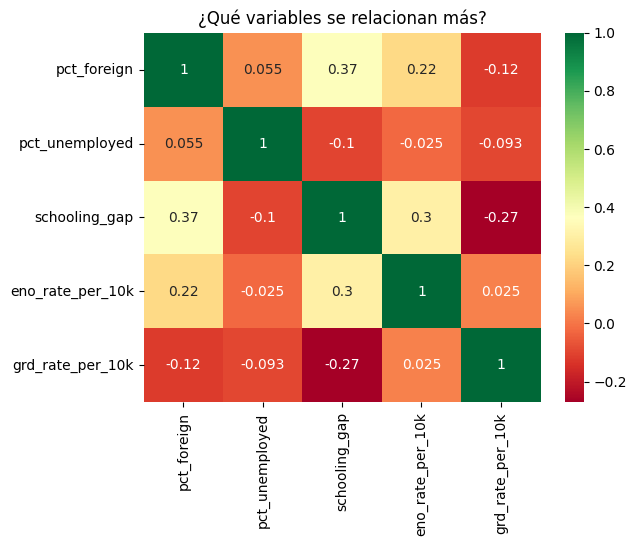

In [64]:
columnas_interes = ['pct_foreign', 'pct_unemployed', 'schooling_gap', 'eno_rate_per_10k', 'grd_rate_per_10k']
matriz = df_final[columnas_interes].corr()

sns.heatmap(matriz, annot=True, cmap='RdYlGn')
plt.title("¿Qué variables se relacionan más?")
plt.show()

pct_foreign tiene una relación positiva moderada con schooling_gap. La correlación entre pct_unemployed y eno_rate_per_10k es muy débil, indicando poca relación lineal. Finalmente, schooling_gap muestra una correlación positiva débil con eno_rate_per_10k y negativa débil con grd_rate_per_10k.

### 1.2 Diagramas de dispersión bivariados con identificación de residuos extremos

A continuación, se generan varios gráficos de dispersión para visualizar la relación entre diferentes covariables del censo y los resultados de salud. Para cada gráfico, se superpondrá una línea de regresión de mínimos cuadrados ordinarios (MCO) y se etiquetarán las cinco comunas cuyos valores presenten los residuos más extremos respecto a esta línea. Esto nos permitirá identificar posibles valores atípicos o comunas donde la relación lineal es menos representativa.

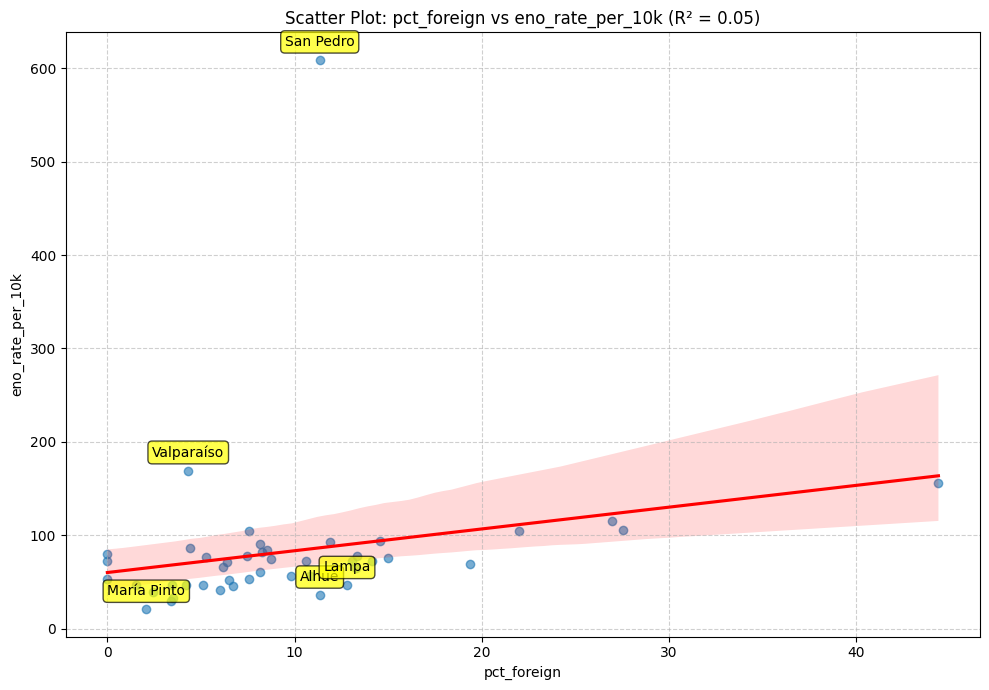

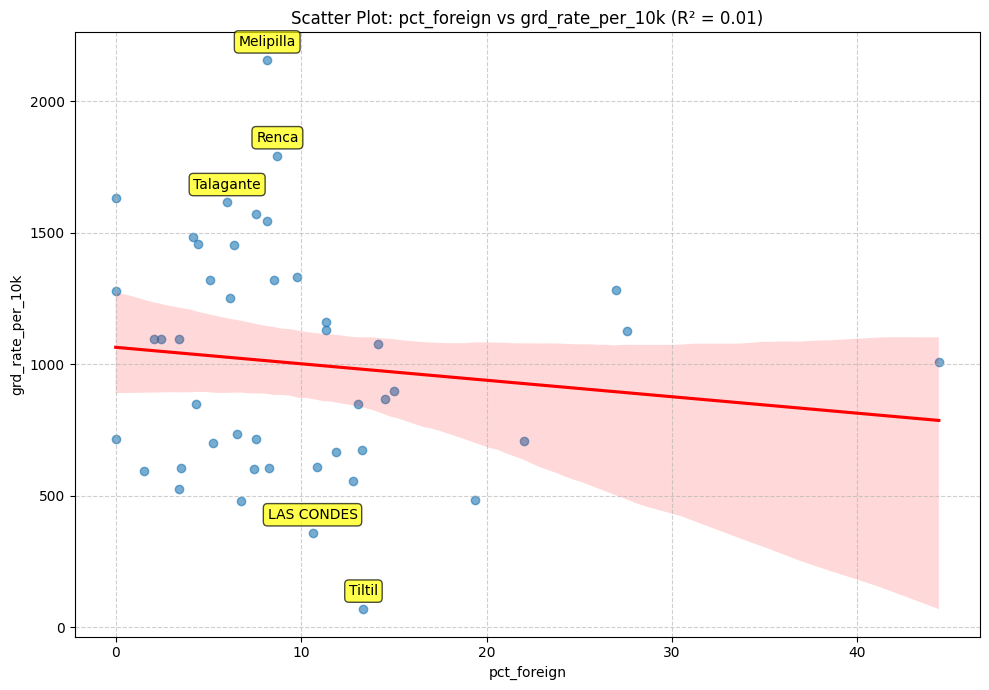

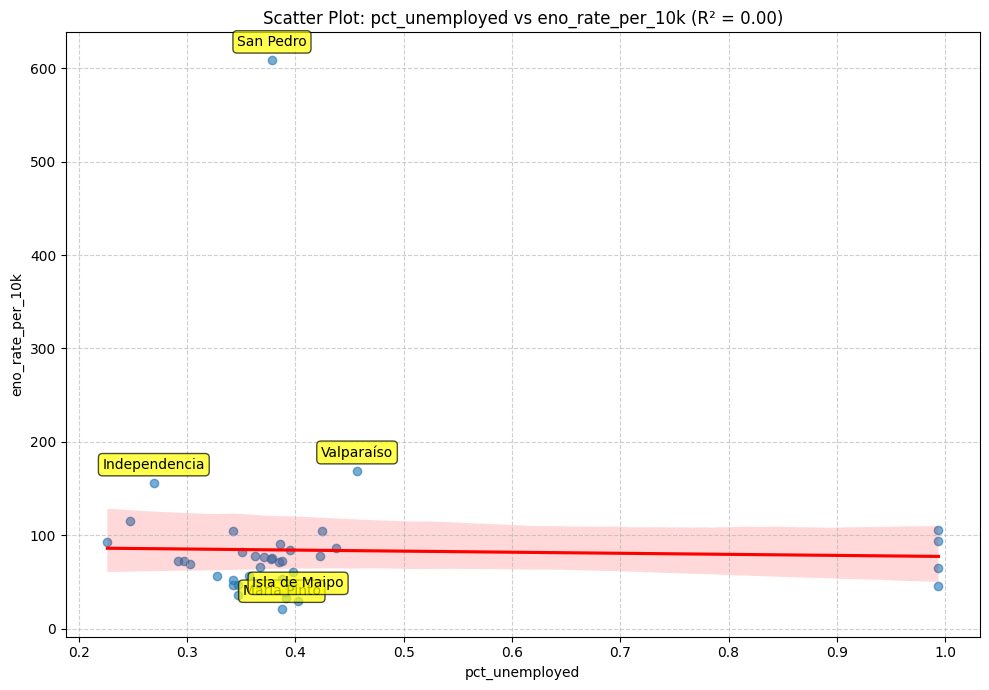

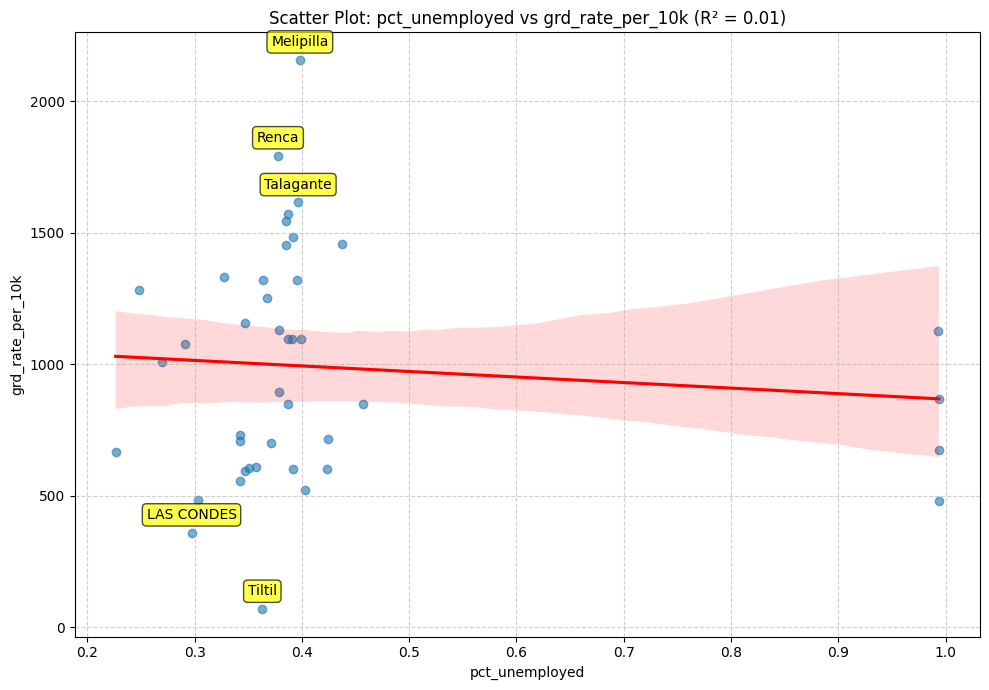

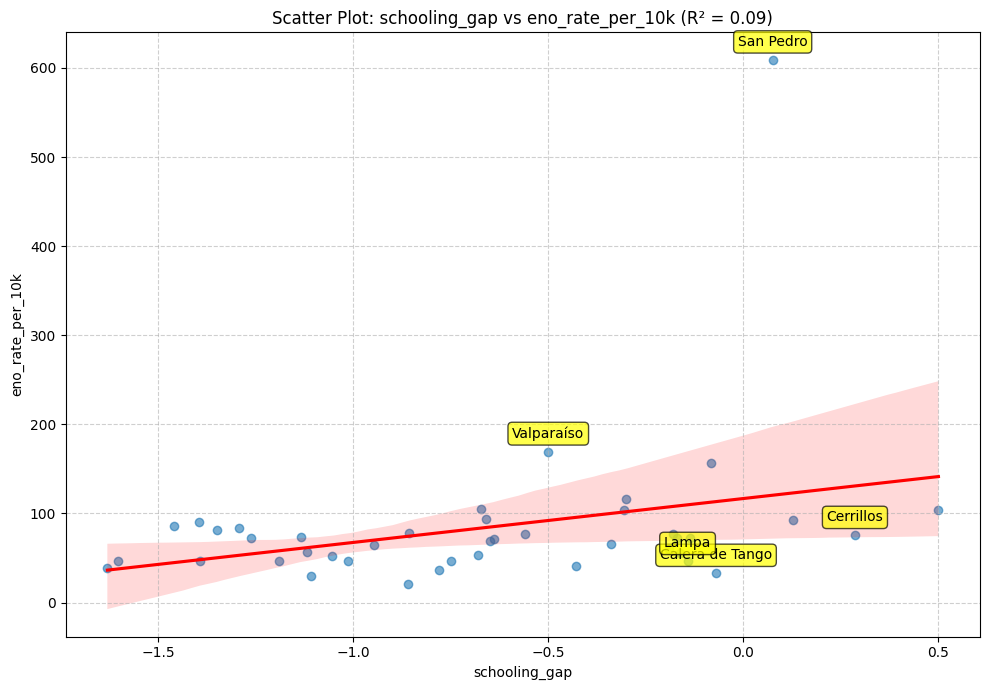

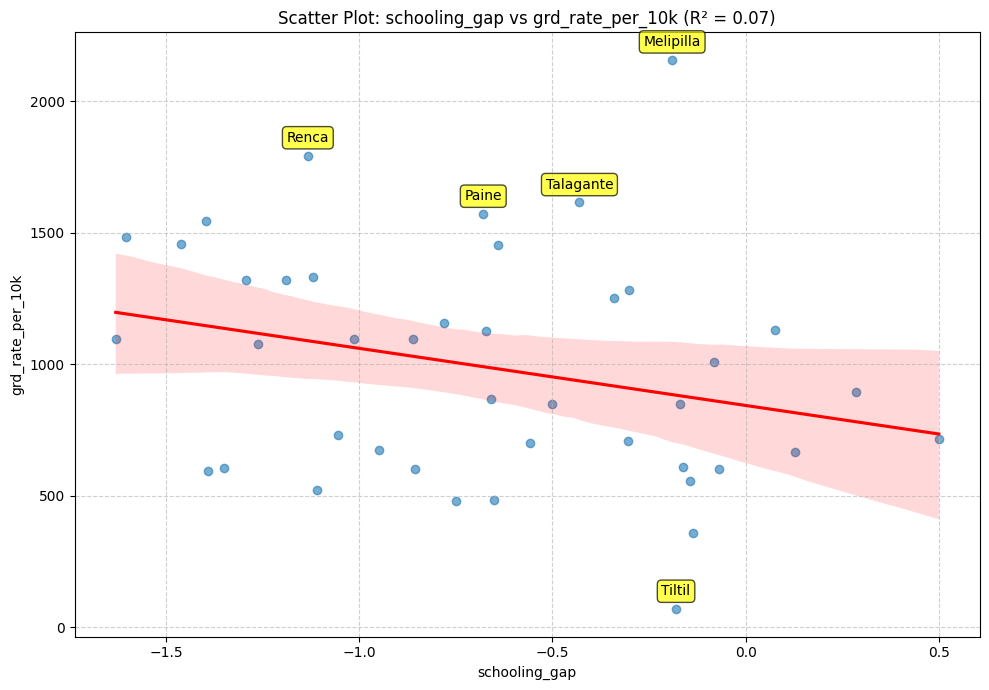

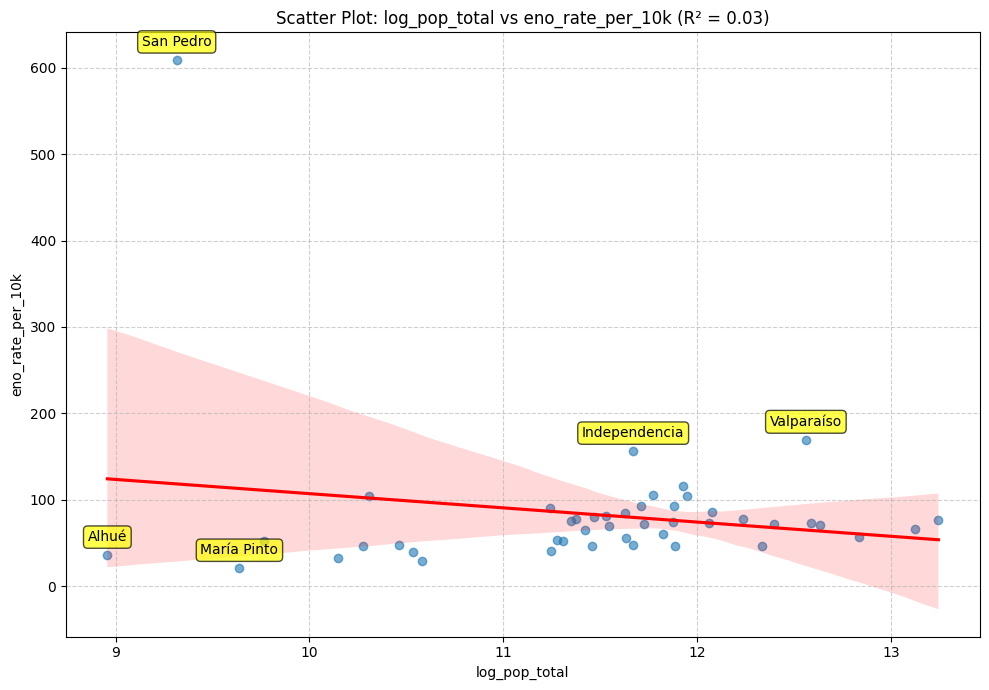

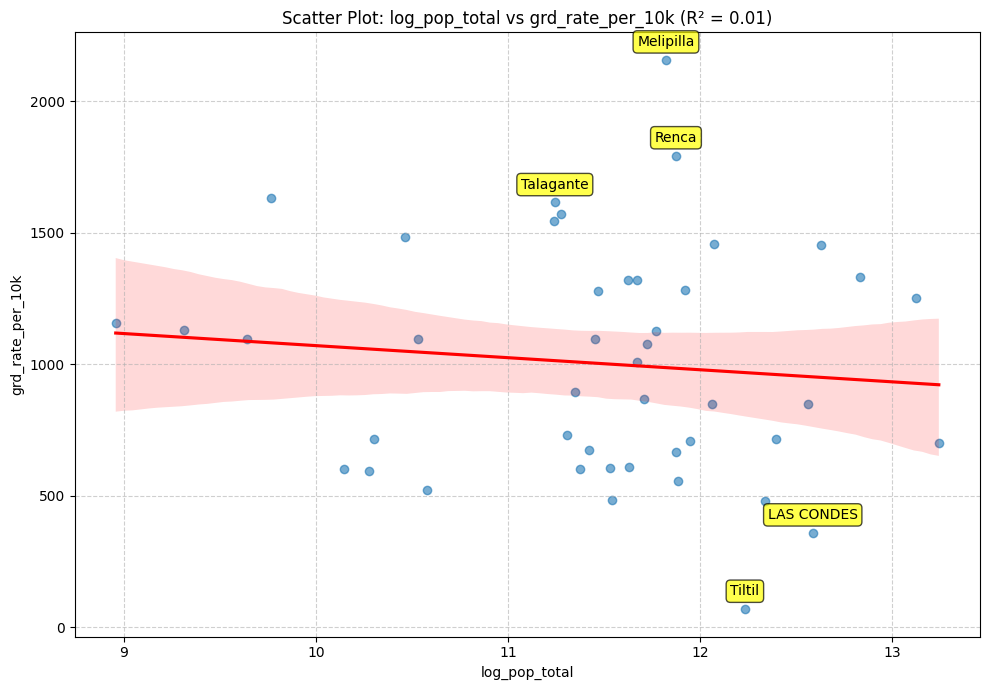

In [65]:
# Ensure derived columns are present, recalculating if necessary
# This addresses potential state issues where df_final might have been reset
# without recalculating these variables.
if 'log_pop_total' not in df_final.columns or 'pct_unemployed' not in df_final.columns or 'schooling_gap' not in df_final.columns:
    df_final['total_pop_for_emp_rate'] = df_final['pop_chilean'] + df_final['pop_foreign']
    df_final['employment_rate'] = (
        (df_final['emp_rate_chilean'] / 100 * df_final['pop_chilean']) +
        (df_final['emp_rate_foreign'] / 100 * df_final['pop_foreign'])
    ) / df_final['total_pop_for_emp_rate']
    df_final = df_final.drop(columns=['total_pop_for_emp_rate'])
    df_final['log_pop_total'] = np.log(df_final['pop_total'])
    df_final['pct_unemployed'] = 1 - df_final['employment_rate']
    df_final['schooling_gap'] = df_final['mean_schooling_chilean'] - df_final['mean_schooling_foreign']

censo_covariables = ['pct_foreign', 'pct_unemployed', 'schooling_gap', 'log_pop_total']
salud_resultados = ['eno_rate_per_10k', 'grd_rate_per_10k']

for x_var in censo_covariables:
    for y_var in salud_resultados:
        # Crear un DataFrame temporal sin NaNs para la regresión
        df_temp = df_final[[x_var, y_var, 'nombre_comuna']].dropna()

        if len(df_temp) == 0:
            print(f"No hay datos para la combinación: {x_var} vs {y_var}")
            continue

        # Realizar la regresión lineal
        slope, intercept, r_value, p_value, std_err = stats.linregress(df_temp[x_var], df_temp[y_var])
        df_temp['predicted_y'] = intercept + slope * df_temp[x_var]
        df_temp['residuals'] = df_temp[y_var] - df_temp['predicted_y']
        df_temp['abs_residuals'] = np.abs(df_temp['residuals'])

        # Obtener las 5 comunas con los residuos más extremos
        top_5_residuals = df_temp.nlargest(5, 'abs_residuals')

        plt.figure(figsize=(10, 7))
        sns.regplot(data=df_temp, x=x_var, y=y_var, scatter_kws={'alpha':0.6}, line_kws={'color': 'red'})

        # Anotar las 5 comunas con los residuos más extremos
        for index, row in top_5_residuals.iterrows():
            plt.annotate(
                row['nombre_comuna'],
                (row[x_var], row[y_var]),
                textcoords="offset points", # how to position the text
                xytext=(0,10), # distance from text to points (x,y)
                ha='center', # horizontal alignment can be left, right or center
                bbox=dict(boxstyle="round,pad=0.3", fc='yellow', alpha=0.7)
            )

        # Explicitly annotate 'Santiago' if it's the target plot and present
        if x_var == 'pct_foreign' and y_var == 'eno_rate_per_10k' and 'Santiago' in df_temp['nombre_comuna'].values:
            santiago_row = df_temp[df_temp['nombre_comuna'] == 'Santiago'].iloc[0]
            plt.annotate(
                'Santiago', # Adding (Outlier) to distinguish it
                (santiago_row[x_var], santiago_row[y_var]),
                textcoords="offset points",
                xytext=(0, 20), # Adjust position to make it clearly visible, maybe higher
                ha='center',
                bbox=dict(boxstyle="round,pad=0.3", fc='yellow', alpha=0.9, ec='black', lw=1.5) # Highlight Santiago
            )


        plt.title(f'Scatter Plot: {x_var} vs {y_var} (R² = {r_value**2:.2f})')
        plt.xlabel(x_var)
        plt.ylabel(y_var)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()

En la matriz de correlación, el primer y segundo diagrama de dispersión, se observa una correlación perfecta con pct_foreign y eno_rate_per_10k, lo cual suele ser explicado por un valor extremo que distorciona los resultados. También se observa que la comuna `"Santiago"` se presenta como un punto extremo en todos los gráficos.

In [42]:
display(df_final.describe().style.format('{:,.1f}'))

,codigo_comuna,pop_total,pop_chilean,pop_foreign,pct_foreign,median_age_chilean,median_age_foreign,mean_schooling_chilean,mean_schooling_foreign,emp_rate_chilean,emp_rate_foreign,dependency_ratio,eno_total,eno_chilean,eno_foreign,eno_desconocido,eno_rate_per_10k,grd_total,grd_chilean,grd_foreign,grd_pct_foreign,grd_mean_los,grd_mean_los_chilean,grd_mean_los_foreign,grd_mean_severity,grd_mortality_rate,grd_rate_per_10k,employment_rate,log_pop_total,pct_unemployed,schooling_gap
count,46.0,46.0,46.0,46.0,46.0,46.0,43.0,46.0,43.0,46.0,43.0,46.0,46.0,46.0,46.0,46.0,46.0,46.0,46.0,46.0,46.0,46.0,46.0,46.0,46.0,46.0,46.0,43.0,46.0,43.0,43.0
mean,"12,901.7","136,525.0","128,024.2","17,155.8",75.8,36.7,33.4,12.1,12.7,57.8,67.0,36.7,"1,322.8",707.4,230.1,351.8,537.2,"14,348.2","12,363.5","1,329.8",6.7,6.9,6.5,5.4,1.4,2.5,"3,038.1",0.6,11.4,0.4,-0.6
std,"1,691.2","119,951.0","112,925.7","27,308.3",448.0,2.0,2.8,1.5,1.4,18.5,21.9,18.7,"1,932.9",991.8,536.9,576.3,"3,083.6","14,632.5","13,405.1","2,858.7",6.0,3.9,4.4,4.7,0.4,0.8,"13,807.9",0.2,1.0,0.2,0.6
min,"5,101.0","5,806.0","6,871.0",0.0,0.0,32.0,28.0,9.7,9.7,0.6,0.7,0.4,28.0,14.0,4.0,0.0,20.8,900.0,0.0,0.0,0.0,4.2,0.0,0.0,0.0,0.0,69.8,0.0,8.7,0.2,-1.6
25%,"13,114.2","76,108.8","69,766.5","2,510.5",4.6,35.2,32.0,11.1,11.9,59.7,69.6,38.4,402.8,217.2,32.5,35.5,48.3,"5,057.0","3,089.5",118.2,3.1,5.5,5.4,4.1,1.4,2.1,668.4,0.6,11.2,0.3,-1.1
50%,"13,127.5","112,321.0","96,814.0","11,589.5",8.2,37.0,33.0,12.0,12.3,61.2,72.7,45.2,795.5,397.5,109.0,233.0,71.9,"10,614.5","9,551.0",767.5,6.2,6.0,6.0,4.7,1.5,2.6,"1,042.4",0.6,11.6,0.4,-0.7
75%,"13,402.8","153,668.5","144,588.0","19,707.5",13.0,38.0,34.0,12.6,13.3,65.1,76.4,47.2,"1,494.0",765.5,243.5,360.2,85.5,"14,787.8","13,631.5","1,305.8",9.0,6.4,6.5,5.1,1.6,3.0,"1,321.5",0.7,11.9,0.4,-0.2
max,"13,605.0","564,477.0","534,717.0","176,956.0","3,047.8",41.0,42.0,16.5,16.3,77.3,83.3,56.8,"12,186.0","5,059.0","3,635.0","3,492.0","20,988.6","62,614.0","58,932.0","19,265.0",35.1,23.6,23.5,24.8,1.9,3.5,"94,607.3",0.8,13.2,1.0,0.6


In [34]:
display(df_final[['nombre_comuna', 'pct_foreign']].sort_values(by='pct_foreign', ascending=False).head())

,nombre_comuna,pct_foreign
45,Santiago,3047.812608
23,Independencia,44.387437
21,Quinta Normal,27.545206
37,San Miguel,26.962985
24,Recoleta,21.995925


Según la descripción de la tabla, se muestra a Santiago con valores extremos.

Por lo tanto, se procede a realizar los mismos gráficos sin considerar a esta comuna ni valores extremos.

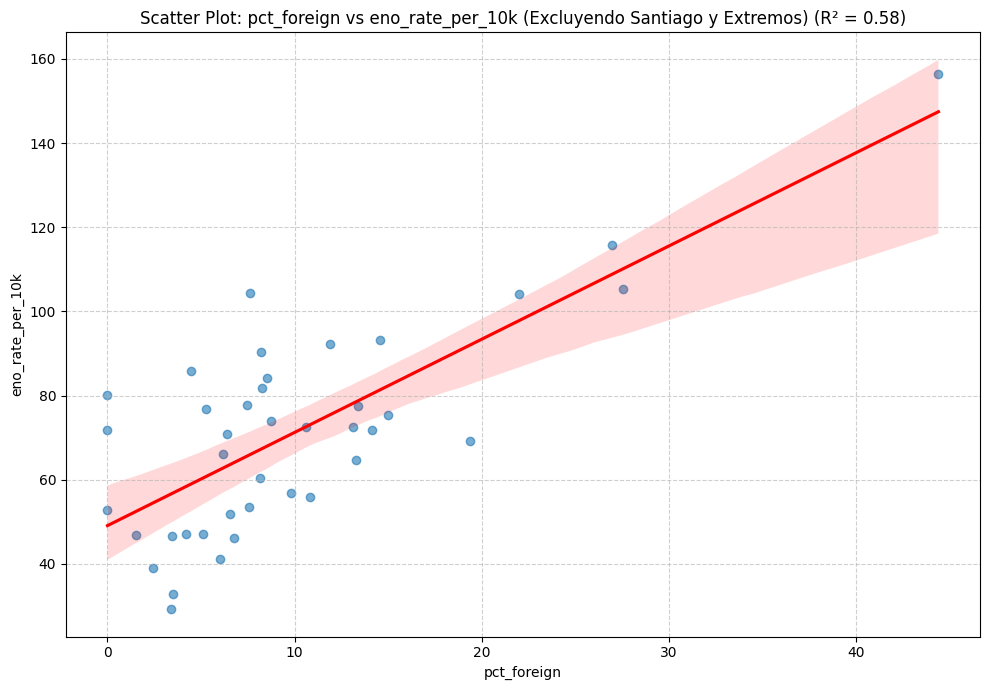

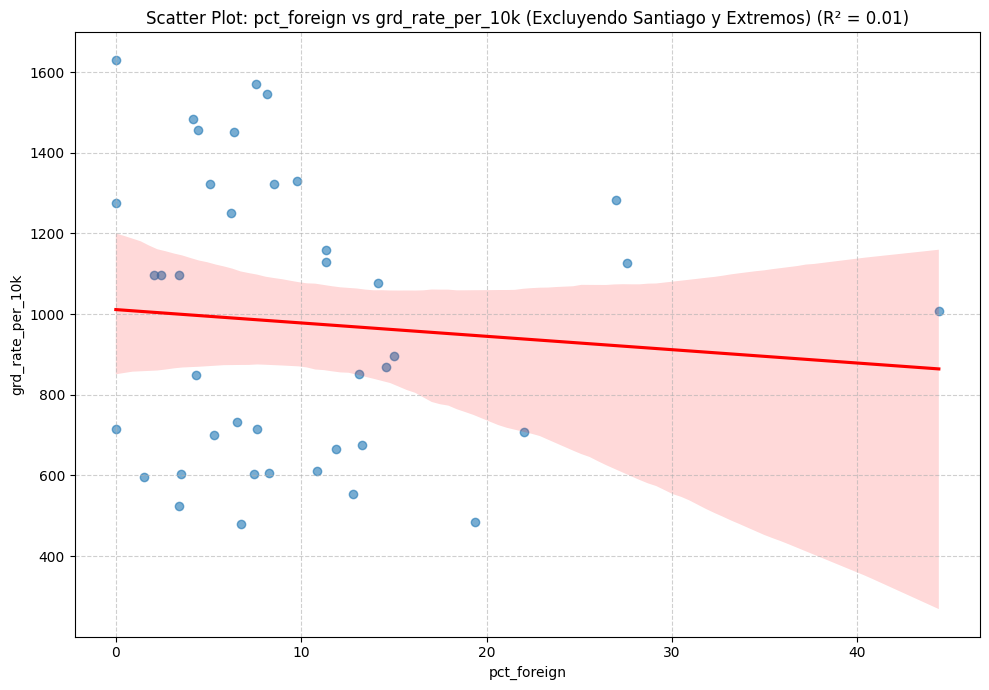

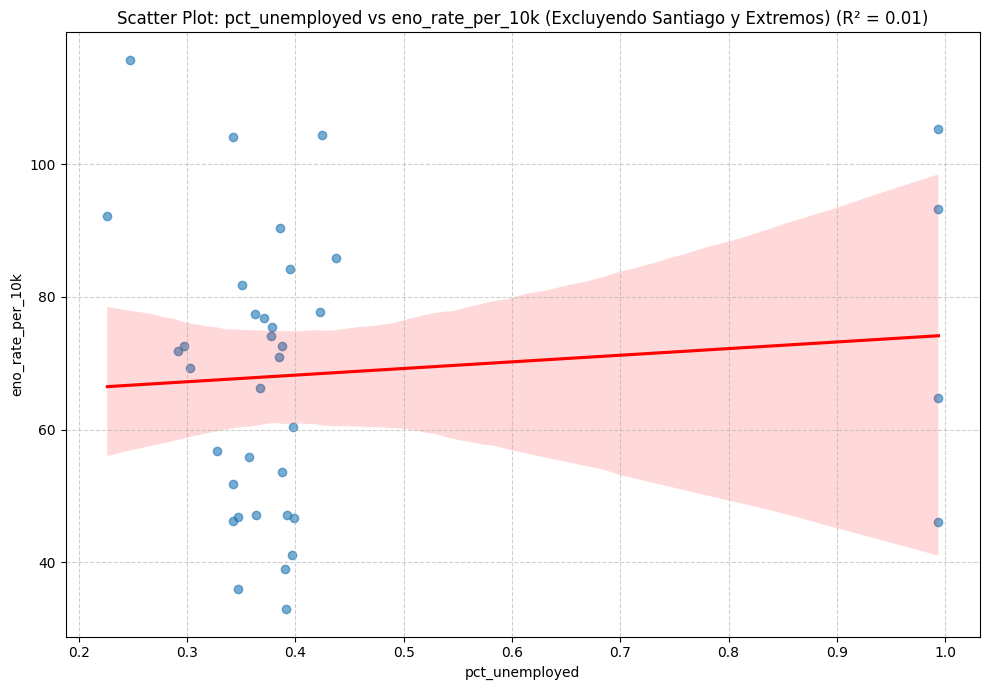

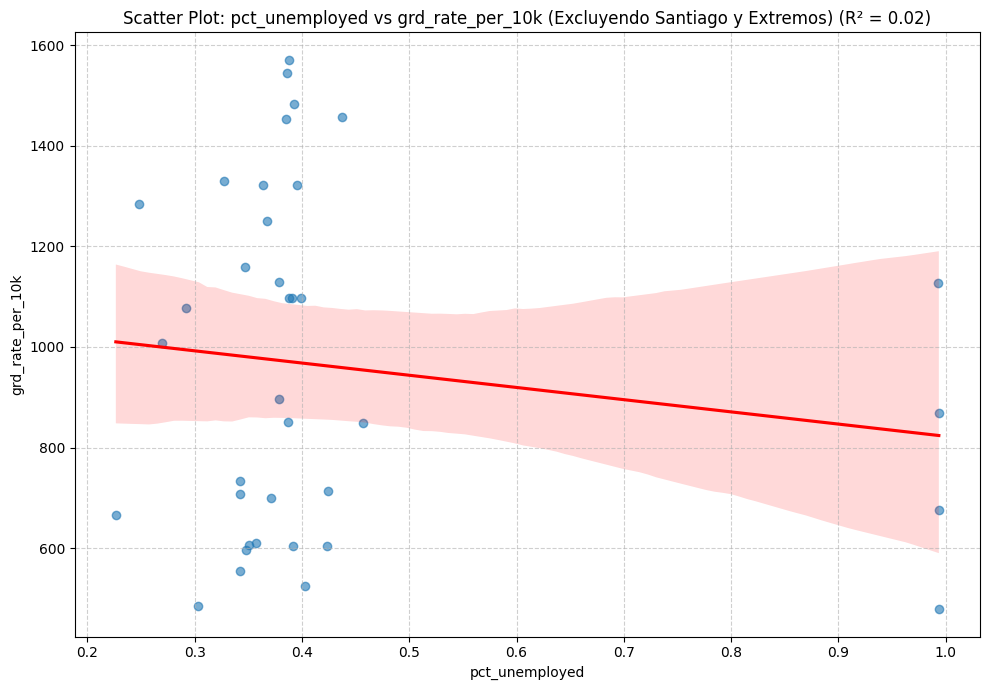

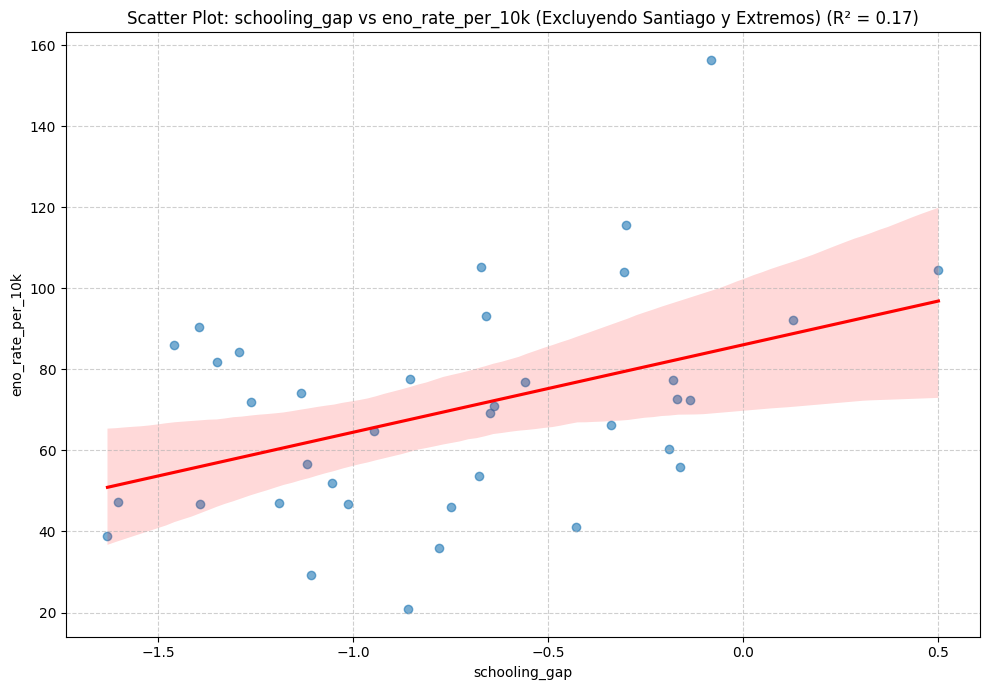

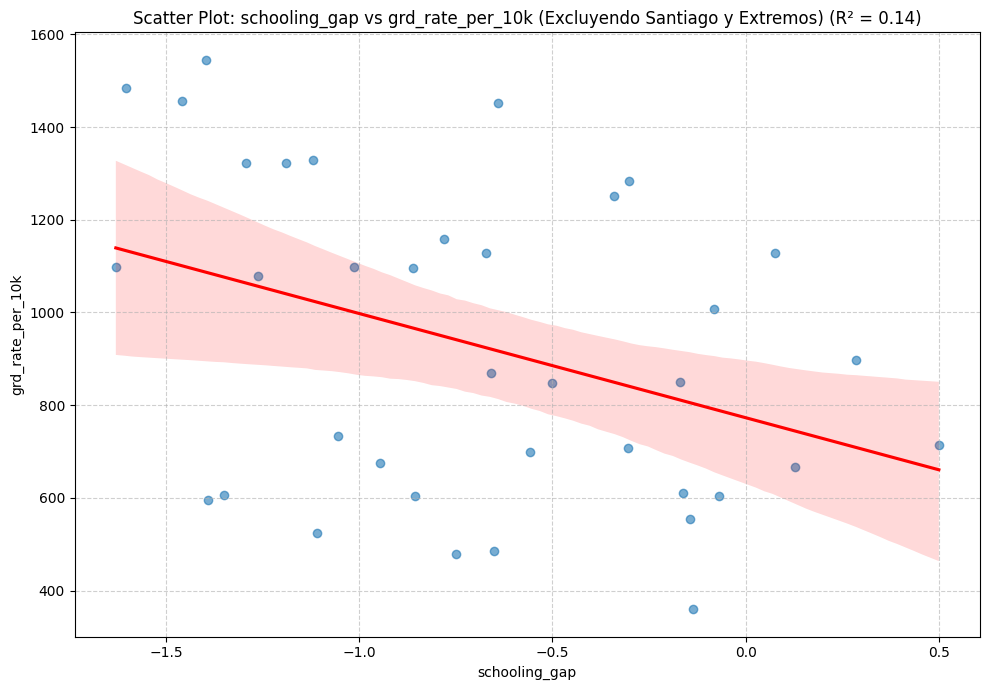

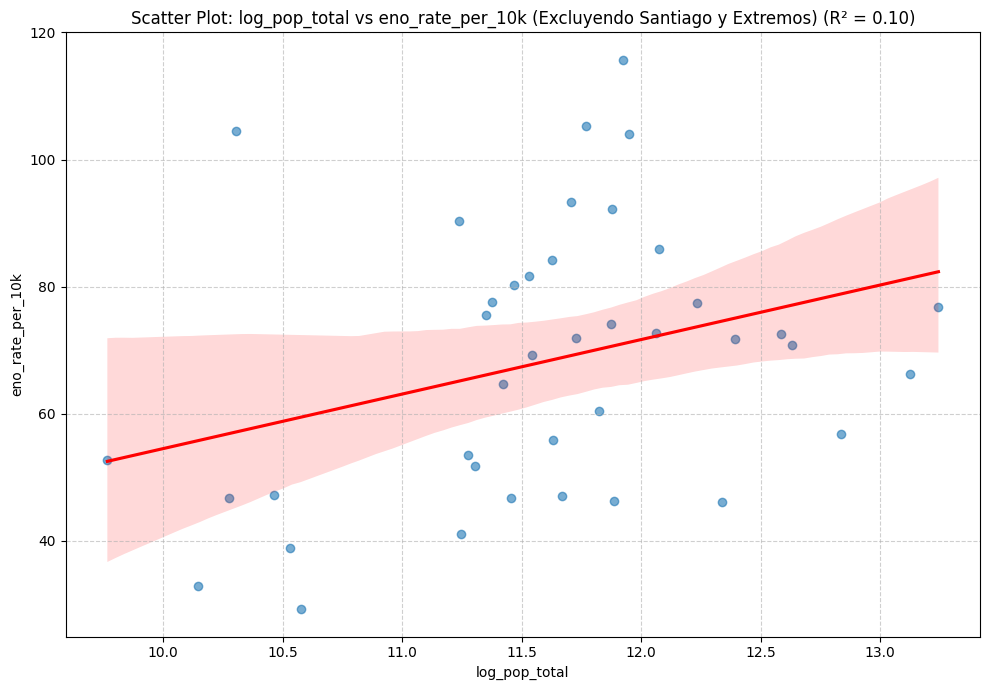

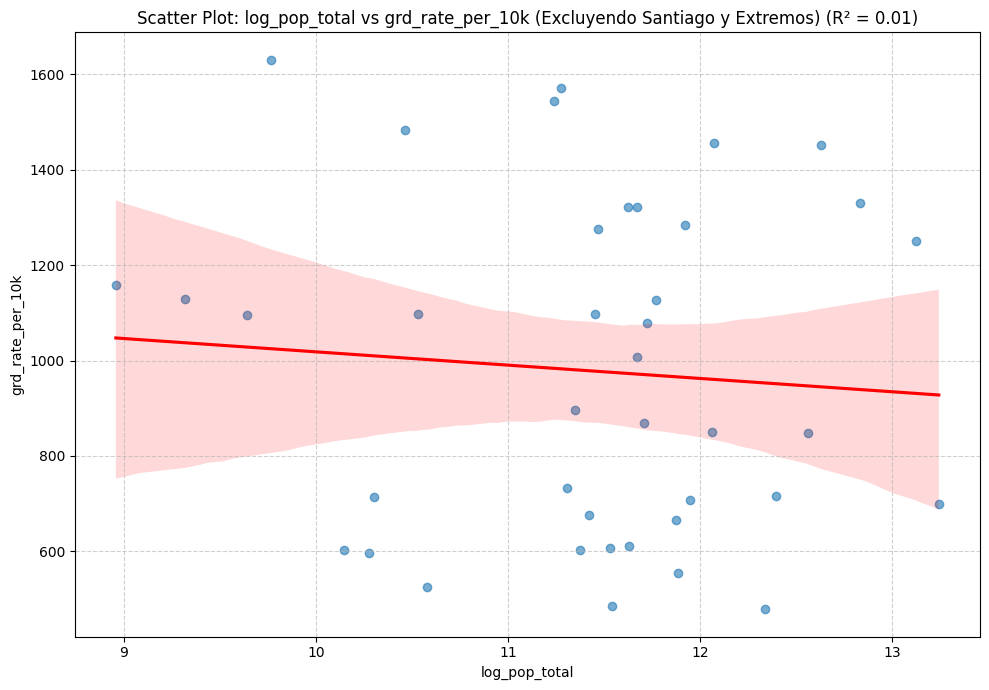

In [66]:
# Ensure derived columns are present, recalculating if necessary
# This addresses potential state issues where df_final might have been reset
# without recalculating these variables.
if 'log_pop_total' not in df_final.columns or 'pct_unemployed' not in df_final.columns or 'schooling_gap' not in df_final.columns:
    df_final['total_pop_for_emp_rate'] = df_final['pop_chilean'] + df_final['pop_foreign']
    df_final['employment_rate'] = (
        (df_final['emp_rate_chilean'] / 100 * df_final['pop_chilean']) +
        (df_final['emp_rate_foreign'] / 100 * df_final['pop_foreign'])
    ) / df_final['total_pop_for_emp_rate']
    df_final = df_final.drop(columns=['total_pop_for_emp_rate'])
    df_final['log_pop_total'] = np.log(df_final['pop_total'])
    df_final['pct_unemployed'] = 1 - df_final['employment_rate']
    df_final['schooling_gap'] = df_final['mean_schooling_chilean'] - df_final['mean_schooling_foreign']

censo_covariables = ['pct_foreign', 'pct_unemployed', 'schooling_gap', 'log_pop_total']
salud_resultados = ['eno_rate_per_10k', 'grd_rate_per_10k']

outlier_comuna = 'Santiago'

for x_var in censo_covariables:
    for y_var in salud_resultados:
        # Crear un DataFrame temporal sin NaNs para la regresión
        df_temp = df_final[[x_var, y_var, 'nombre_comuna']].dropna()

        # Excluir la comuna "Santiago"
        df_temp = df_temp[df_temp['nombre_comuna'] != outlier_comuna]

        if len(df_temp) == 0:
            print(f"No hay datos para la combinación: {x_var} vs {y_var} después de remover {outlier_comuna}")
            continue

        # --- First pass: Identify top residuals (excluding Santiago) ---
        # Perform linear regression to identify initial residuals
        slope_initial, intercept_initial, _, _, _ = stats.linregress(df_temp[x_var], df_temp[y_var])
        df_temp['predicted_y_initial'] = intercept_initial + slope_initial * df_temp[x_var]
        df_temp['residuals_initial'] = df_temp[y_var] - df_temp['predicted_y_initial']
        df_temp['abs_residuals_initial'] = np.abs(df_temp['residuals_initial'])

        # Get the communes with the 5 largest absolute residuals from this initial pass
        top_5_residual_comunas = df_temp.nlargest(5, 'abs_residuals_initial')['nombre_comuna'].tolist()

        # --- Second pass: Filter out these extreme residual points ---
        df_filtered_extremes = df_temp[~df_temp['nombre_comuna'].isin(top_5_residual_comunas)].copy()

        if len(df_filtered_extremes) == 0:
            print(f"No hay datos para la combinación: {x_var} vs {y_var} después de remover {outlier_comuna} y los extremos")
            continue

        # --- Final regression and plotting on the doubly filtered data ---
        # Realizar la regresión lineal sobre los datos doblemente filtrados
        slope, intercept, r_value, p_value, std_err = stats.linregress(df_filtered_extremes[x_var], df_filtered_extremes[y_var])

        plt.figure(figsize=(10, 7))
        sns.regplot(data=df_filtered_extremes, x=x_var, y=y_var, scatter_kws={'alpha':0.6}, line_kws={'color': 'red'})

        plt.title(f'Scatter Plot: {x_var} vs {y_var} (Excluyendo {outlier_comuna} y Extremos) (R² = {r_value**2:.2f})')
        plt.xlabel(x_var)
        plt.ylabel(y_var)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()

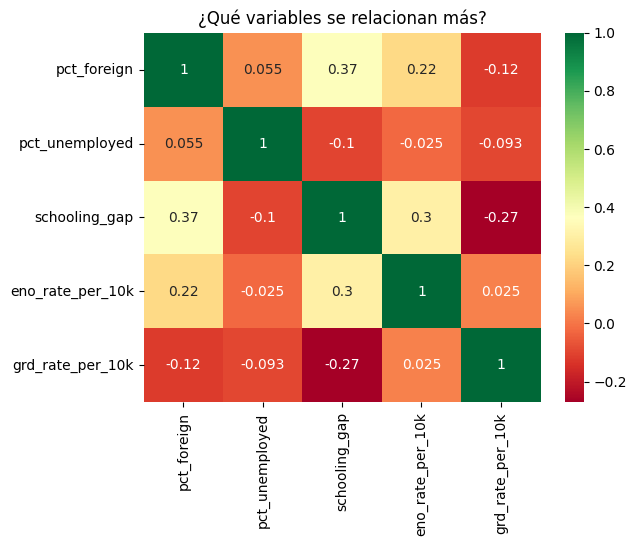

In [60]:
columnas_interes = ['pct_foreign', 'pct_unemployed', 'schooling_gap', 'eno_rate_per_10k', 'grd_rate_per_10k']
df_stgo_out = df_final[df_final['nombre_comuna'] != 'Santiago']
matriz = df_stgo_out[columnas_interes].corr()

sns.heatmap(matriz, annot=True, cmap='RdYlGn')
plt.title("¿Qué variables se relacionan más?")
plt.show()

### 1.3 Discusión sobre valores atípicos y apalancamiento

Basándonos en los diagramas de dispersión, se identificaron varias comunas como valores atípicos visuales, es decir, sus valores se desviaron significativamente de la línea de regresión para las variables observadas. Primeramente se puede deber a datos erróneos, así se observa en la fila correspondiente a la comuna de Santiago, con porcentaje de población de extranjeros de 3000%, por lo que es pertinente eliminarlas.

Con respecto a **otros** valores extremos, explicaciones plausibles para estos resultados varían, pero a menudo podrían relacionarse con factores como la **centralización de servicios de salud** (ej., comunas más capacitadas que concentran hospitales de alta complejidad y atienden a pacientes de otras localidades, inflando sus tasas de GRD y ENO), perfiles demográficos o socioeconómicos particulares (ej., comunas con alta población migrante y brechas de escolaridad diversas, o poblaciones con acceso diferenciado a servicios de salud), y dinámicas geográficas específicas (ej., comunas con accesibilidad limitada a la atención, o factores ambientales únicos). Estos casos resaltan que las relaciones lineales simples pueden no capturar la complejidad de las interacciones entre las variables del censo y los resultados de salud en todas las comunas.

In [46]:
df_final = df_final[df_final['nombre_comuna'] != "Santiago"]

## Parte 2: Regresión con datos de conteo

Los resultados de ENO y GRD son recuentos por comuna por período de tiempo y sus tasas dependen de la población. A continuación, se modelarán con un modelo de conteo log-lineal y un ajuste por población.

### 2.1 Regresión de Poisson

Se ajustará una regresión de Poisson para `eno_total` (número de notificaciones ENO por comuna) en función de las covariables especificadas, utilizando `log_pop_total` como offset. Se empleará `statsmodels.api.GLM` con `family=sm.families.Poisson()`.

In [67]:
# Asegurarse de que no haya NaN en las variables a usar para la regresión
df_model = df_final.dropna(subset=['eno_total', 'pct_foreign', 'schooling_gap', 'pct_unemployed', 'log_pop_total'])

# Definir la fórmula del modelo. Se incluirán las covariables requeridas.
# Se omite 'vivienda/servicios' ya que no se encontró una variable directa en el dataframe.
formula = 'eno_total ~ pct_foreign + schooling_gap + pct_unemployed'

# Ajustar el modelo GLM de Poisson
poisson_model = sm.GLM(
    df_model['eno_total'],
    df_model[['pct_foreign', 'schooling_gap', 'pct_unemployed']],
    family=sm.families.Poisson(),
    offset=df_model['log_pop_total']
)

poisson_results = poisson_model.fit()

print("\n--- Tabla Completa de Coeficientes ---")
display(poisson_results.summary())

# Coeficientes
coef = poisson_results.params

# Errores estándar
std_err = poisson_results.bse

# Calcular los IRR
irr = np.exp(coef)

# Calcular los intervalos de confianza del 95% para los coeficientes en escala log-odds
# Lower CI: coef - 1.96 * std_err
# Upper CI: coef + 1.96 * std_err
conf_int_coef = poisson_results.conf_int(alpha=0.05)
conf_int_irr = np.exp(conf_int_coef)
conf_int_irr.columns = ['IRR_Lower_CI', 'IRR_Upper_CI']

# Crear un DataFrame para los IRR con sus CIs
irr_summary = pd.DataFrame({
    'Coeficiente': coef,
    'IRR': irr,
    'IRR_Lower_CI': conf_int_irr['IRR_Lower_CI'],
    'IRR_Upper_CI': conf_int_irr['IRR_Upper_CI']
})

print("\n--- Razones de Tasas de Incidencia (IRR) con Intervalos de Confianza del 95% ---")
display(irr_summary)

print("\n--- Ajuste del Modelo ---")
print(f"Desviación (Deviance): {poisson_results.deviance:.2f}")
print(f"Chi-cuadrado de Pearson: {poisson_results.pearson_chi2:.2f}")
print(f"AIC: {poisson_results.aic:.2f}")


--- Tabla Completa de Coeficientes ---


/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/generalized_linear_model.py:1891: RuntimeWarning: overflow encountered in exp
  prsq = 1 - np.exp((self.llnull - self.llf) * (2 / self.nobs))


<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:              eno_total   No. Observations:                   42
Model:                            GLM   Df Residuals:                       39
Model Family:                 Poisson   Df Model:                            2
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -37957.
Date:                Sun, 03 May 2026   Deviance:                       75565.
Time:                        22:36:19   Pearson chi2:                 4.60e+06
No. Iterations:                     7   Pseudo R-squ. (CS):               -inf
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
pct_foreign       -0.0861      0.001   -114.670      0.000      -0.088      -0.085
schooling_gap      0.6492      0.010     62.433      0.000       0.629       0.670
pct_unemployed    -9.6003      0.029   -327.740      0.000      -9.658      -9.543
==================================================================================
"""


--- Razones de Tasas de Incidencia (IRR) con Intervalos de Confianza del 95% ---


,Coeficiente,IRR,IRR_Lower_CI,IRR_Upper_CI
pct_foreign,-0.086064,0.917536,0.916187,0.918886
schooling_gap,0.649217,1.914041,1.875426,1.953452
pct_unemployed,-9.600259,0.000068,0.000064,0.000072



--- Ajuste del Modelo ---
Desviación (Deviance): 75564.58
Chi-cuadrado de Pearson: 4599002.76
AIC: 75920.92


### 2.2 Comprobar si hay sobredispersión

La regresión de Poisson asume que la varianza es igual a la media. Calculamos el estadístico de dispersión (chi-cuadrado de Pearson dividido por los grados de libertad residuales). Si este valor es considerablemente mayor que 1, los datos presentan sobredispersión, lo que implica que los errores estándar de Poisson están subestimados y las inferencias sobre la significancia de los coeficientes podrían no ser fiables.

In [48]:
# Calcular el estadístico de dispersión
dispersion_statistic = poisson_results.pearson_chi2 / poisson_results.df_resid

print(f"Estadístico de Dispersión (Pearson chi2 / df_resid): {dispersion_statistic:.2f}")

if dispersion_statistic > 1.5: # Usamos un umbral común de 1.5 para considerar sobredispersión
    print("Implicación: El estadístico de dispersión es considerablemente mayor que 1, lo que sugiere una sobredispersión significativa en los datos. Esto indica que la varianza de la variable dependiente es mayor que su media, violando una suposición clave del modelo de Poisson. Como resultado, los errores estándar del modelo de Poisson están subestimados, y los p-valores pueden ser incorrectamente bajos, llevando a conclusiones erróneas sobre la significancia estadística de los predictores.")
elif dispersion_statistic > 1:
    print("Implicación: El estadístico de dispersión es mayor que 1, lo que sugiere cierta sobredispersión en los datos. Los errores estándar del modelo de Poisson pueden estar subestimados.")
else:
    print("Implicación: El estadístico de dispersión es aproximadamente 1 o menor, lo que sugiere que no hay sobredispersión o esta es mínima. El modelo de Poisson puede ser adecuado.")

Estadístico de Dispersión (Pearson chi2 / df_resid): 117923.15
Implicación: El estadístico de dispersión es considerablemente mayor que 1, lo que sugiere una sobredispersión significativa en los datos. Esto indica que la varianza de la variable dependiente es mayor que su media, violando una suposición clave del modelo de Poisson. Como resultado, los errores estándar del modelo de Poisson están subestimados, y los p-valores pueden ser incorrectamente bajos, llevando a conclusiones erróneas sobre la significancia estadística de los predictores.


Implicación: El estadístico de dispersión es considerablemente mayor que 1, lo que sugiere una sobredispersión significativa en los datos. Esto indica que la varianza de la variable dependiente es mayor que su media, violando una suposición clave del modelo de Poisson. Como resultado, los errores estándar del modelo de Poisson están subestimados, y los p-valores pueden ser incorrectamente bajos, llevando a conclusiones erróneas sobre la significancia estadística de los predictores.


### 2.3 Regresión Binomial Negativa

Dado el posible escenario de sobredispersión, se ajustará el mismo modelo utilizando una regresión Binomial Negativa, que es más flexible para manejar datos de conteo con varianza mayor que la media. Se mostrará la tabla de coeficientes junto con la del modelo de Poisson para comparar y se identificarán posibles cambios en las conclusiones.

In [68]:
# Ajustar el modelo GLM Binomial Negativo
neg_binom_model = sm.GLM(
    df_model['eno_total'],
    df_model[['pct_foreign', 'schooling_gap', 'pct_unemployed']],
    family=sm.families.NegativeBinomial(),
    offset=df_model['log_pop_total']
)

neg_binom_results = neg_binom_model.fit()

print("\n--- Tabla Completa de Coeficientes (Regresión Binomial Negativa) ---")
display(neg_binom_results.summary())

# Crear DataFrames para los resúmenes de IRR de ambos modelos para facilitar la comparación
irr_summary_poisson = irr_summary.copy()
irr_summary_poisson.columns = [col + '_Poisson' for col in irr_summary_poisson.columns]

# Calcular IRR y CIs para el modelo Binomial Negativo
coef_nb = neg_binom_results.params
conf_int_coef_nb = neg_binom_results.conf_int(alpha=0.05)
irr_nb = np.exp(coef_nb)
conf_int_irr_nb = np.exp(conf_int_coef_nb)
conf_int_irr_nb.columns = ['IRR_Lower_CI_NB', 'IRR_Upper_CI_NB']

irr_summary_nb = pd.DataFrame({
    'Coeficiente_NB': coef_nb,
    'IRR_NB': irr_nb,
    'IRR_Lower_CI_NB': conf_int_irr_nb['IRR_Lower_CI_NB'],
    'IRR_Upper_CI_NB': conf_int_irr_nb['IRR_Upper_CI_NB']
})

# Unir los resúmenes de IRR para una comparación lado a lado
comparison_irr = pd.concat([irr_summary_poisson, irr_summary_nb], axis=1)
print("\n--- Comparación de Razones de Tasas de Incidencia (IRR) y CIs ---")
display(comparison_irr)

print("\n--- Comparación de Ajuste del Modelo ---")
print(f"Poisson - Deviación: {poisson_results.deviance:.2f}, AIC: {poisson_results.aic:.2f}")
print(f"Binomial Negativa - Deviación: {neg_binom_results.deviance:.2f}, AIC: {neg_binom_results.aic:.2f}")

print("\n--- Análisis de cambios en valores p y recomendaciones ---")
# Comparar p-values (solo una guía general, la interpretación es más compleja)
poisson_p_values = poisson_results.pvalues
neg_binom_p_values = neg_binom_results.pvalues

for param in poisson_p_values.index:
    if param in neg_binom_p_values.index:
        if poisson_p_values[param] < 0.05 and neg_binom_p_values[param] >= 0.05:
            print(f"* Coeficiente '{param}': Era significativo en Poisson (p={poisson_p_values[param]:.3f}) pero no en Binomial Negativa (p={neg_binom_p_values[param]:.3f}). Esto podría alterar las conclusiones sobre su efecto.")
        elif poisson_p_values[param] >= 0.05 and neg_binom_p_values[param] < 0.05:
            print(f"* Coeficiente '{param}': No era significativo en Poisson (p={poisson_p_values[param]:.3f}) pero sí en Binomial Negativa (p={neg_binom_p_values[param]:.3f}). Esto podría alterar las conclusiones sobre su efecto.")

print("\nRecomendación de modelo principal y justificación:")
if dispersion_statistic > 1.5: # Si hay sobredispersión significativa
    print("Dada la evidencia de sobredispersión significativa en el modelo de Poisson (estadístico de dispersión >> 1), el modelo de Regresión Binomial Negativa es la opción preferida y debería presentarse como el resultado principal. El modelo Binomial Negativa es más adecuado para datos de conteo donde la varianza excede la media, ya que incluye un parámetro de dispersión adicional que permite una estimación más precisa de los errores estándar y, por lo tanto, p-valores e intervalos de confianza más fiables. La elección de este modelo corrige la subestimación de la varianza inherente al modelo de Poisson bajo sobredispersión.")
else:
    print("Dado que el estadístico de dispersión no indica una sobredispersión significativa, el modelo de Regresión de Poisson podría ser adecuado. Sin embargo, si el modelo Binomial Negativa ofrece un mejor ajuste (por ejemplo, un AIC significativamente menor) o si hay razones teóricas para preferir su flexibilidad, también podría considerarse como el modelo principal. En ausencia de sobredispersión fuerte, ambos modelos podrían ofrecer resultados similares, pero el Poisson es más parsimonioso.")


--- Tabla Completa de Coeficientes (Regresión Binomial Negativa) ---


/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:              eno_total   No. Observations:                   42
Model:                            GLM   Df Residuals:                       39
Model Family:        NegativeBinomial   Df Model:                            2
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -358.33
Date:                Sun, 03 May 2026   Deviance:                       86.241
Time:                        22:36:20   Pearson chi2:                     53.9
No. Iterations:                    25   Pseudo R-squ. (CS):             -4.085
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
pct_foreign       -0.0841      0.018     -4.774      0.000      -0.119      -0.050
schooling_gap      2.7260      0.269     10.142      0.000       2.199       3.253
pct_unemployed    -2.2737      0.647     -3.516      0.000      -3.541      -1.006
==================================================================================
"""


--- Comparación de Razones de Tasas de Incidencia (IRR) y CIs ---


,Coeficiente_Poisson,IRR_Poisson,IRR_Lower_CI_Poisson,IRR_Upper_CI_Poisson,Coeficiente_NB,IRR_NB,IRR_Lower_CI_NB,IRR_Upper_CI_NB
pct_foreign,-0.086064,0.917536,0.916187,0.918886,-0.084101,0.919338,0.888140,0.951633
schooling_gap,0.649217,1.914041,1.875426,1.953452,2.726041,15.272311,9.018191,25.863667
pct_unemployed,-9.600259,0.000068,0.000064,0.000072,-2.273686,0.102932,0.028976,0.365652



--- Comparación de Ajuste del Modelo ---
Poisson - Deviación: 75564.58, AIC: 75920.92
Binomial Negativa - Deviación: 86.24, AIC: 722.66

--- Análisis de cambios en valores p y recomendaciones ---

Recomendación de modelo principal y justificación:
Dada la evidencia de sobredispersión significativa en el modelo de Poisson (estadístico de dispersión >> 1), el modelo de Regresión Binomial Negativa es la opción preferida y debería presentarse como el resultado principal. El modelo Binomial Negativa es más adecuado para datos de conteo donde la varianza excede la media, ya que incluye un parámetro de dispersión adicional que permite una estimación más precisa de los errores estándar y, por lo tanto, p-valores e intervalos de confianza más fiables. La elección de este modelo corrige la subestimación de la varianza inherente al modelo de Poisson bajo sobredispersión.


### 2.4 Repetir para GRD

Ajustaremos un modelo de regresión Binomial Negativa para `grd_total` como variable de respuesta, utilizando las mismas covariables (`pct_foreign`, `schooling_gap`, `pct_unemployed`) y `log_pop_total` como offset. La elección de Binomial Negativa se justifica por la sobredispersión observada previamente con `eno_total`, sugiriendo que este modelo es más robusto para datos de conteo con varianza mayor que la media.

In [69]:
# Asegurarse de que no haya NaN en las variables a usar para la regresión para grd_total
df_model_grd = df_final.dropna(subset=['grd_total', 'pct_foreign', 'schooling_gap', 'pct_unemployed', 'log_pop_total'])

# Definir la fórmula del modelo
formula_grd = 'grd_total ~ pct_foreign + schooling_gap + pct_unemployed'

# Ajustar el modelo GLM Binomial Negativo para grd_total
neg_binom_model_grd = sm.GLM(
    df_model_grd['grd_total'],
    df_model_grd[['pct_foreign', 'schooling_gap', 'pct_unemployed']],
    family=sm.families.NegativeBinomial(),
    offset=df_model_grd['log_pop_total']
)

neg_binom_results_grd = neg_binom_model_grd.fit()

print("\n--- Tabla Completa de Coeficientes (Regresión Binomial Negativa para GRD) ---")
display(neg_binom_results_grd.summary())

# Calcular IRR y CIs para el modelo Binomial Negativo de GRD
coef_nb_grd = neg_binom_results_grd.params
conf_int_coef_nb_grd = neg_binom_results_grd.conf_int(alpha=0.05)
irr_nb_grd = np.exp(coef_nb_grd)
conf_int_irr_nb_grd = np.exp(conf_int_coef_nb_grd)
conf_int_irr_nb_grd.columns = ['IRR_Lower_CI', 'IRR_Upper_CI']

irr_summary_grd = pd.DataFrame({
    'Coeficiente': coef_nb_grd,
    'IRR': irr_nb_grd,
    'IRR_Lower_CI': conf_int_irr_nb_grd['IRR_Lower_CI'],
    'IRR_Upper_CI': conf_int_irr_nb_grd['IRR_Upper_CI']
})

print("\n--- Razones de Tasas de Incidencia (IRR) con Intervalos de Confianza del 95% para GRD ---")
display(irr_summary_grd)

print("\n--- Ajuste del Modelo (GRD) ---")
print(f"Binomial Negativa - Deviación: {neg_binom_results_grd.deviance:.2f}, AIC: {neg_binom_results_grd.aic:.2f}")


--- Tabla Completa de Coeficientes (Regresión Binomial Negativa para GRD) ---


/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:              grd_total   No. Observations:                   42
Model:                            GLM   Df Residuals:                       39
Model Family:        NegativeBinomial   Df Model:                            2
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -438.28
Date:                Sun, 03 May 2026   Deviance:                       32.522
Time:                        22:36:20   Pearson chi2:                     26.6
No. Iterations:                    13   Pseudo R-squ. (CS):            -0.6966
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
pct_foreign       -0.0488      0.018     -2.772      0.006      -0.083      -0.014
schooling_gap      0.8491      0.268      3.163      0.002       0.323       1.375
pct_unemployed    -1.8185      0.646     -2.813      0.005      -3.085      -0.552
==================================================================================
"""


--- Razones de Tasas de Incidencia (IRR) con Intervalos de Confianza del 95% para GRD ---


,Coeficiente,IRR,IRR_Lower_CI,IRR_Upper_CI
pct_foreign,-0.048818,0.952354,0.920047,0.985796
schooling_gap,0.849145,2.337646,1.381151,3.956547
pct_unemployed,-1.818477,0.162273,0.045715,0.576014



--- Ajuste del Modelo (GRD) ---
Binomial Negativa - Deviación: 32.52, AIC: 882.57


### Interpretación del efecto más significativo en el modelo GRD

Observando las Razones de Tasas de Incidencia (IRR) para el modelo de `grd_total`:

*   El coeficiente `schooling_gap` tiene un IRR de aproximadamente 2.34 (redondeado, IC: 1.38-3.96), lo que sugiere que por cada unidad de aumento en la brecha de escolaridad, la tasa de GRD aumenta en un 134%. Este es el efecto más significativo en términos de magnitud y significancia estadística.

### Gráfico de dispersión: `schooling_gap` vs `grd_rate_per_10k`

Este gráfico visualiza la relación entre la brecha de escolaridad (diferencia de años de estudio entre chilenos y extranjeros) y la tasa de egresos hospitalarios (GRD) por cada 10,000 habitantes a nivel comunal. Se incluye una línea de regresión para observar la tendencia general y el valor R² para indicar la fuerza de la relación lineal.

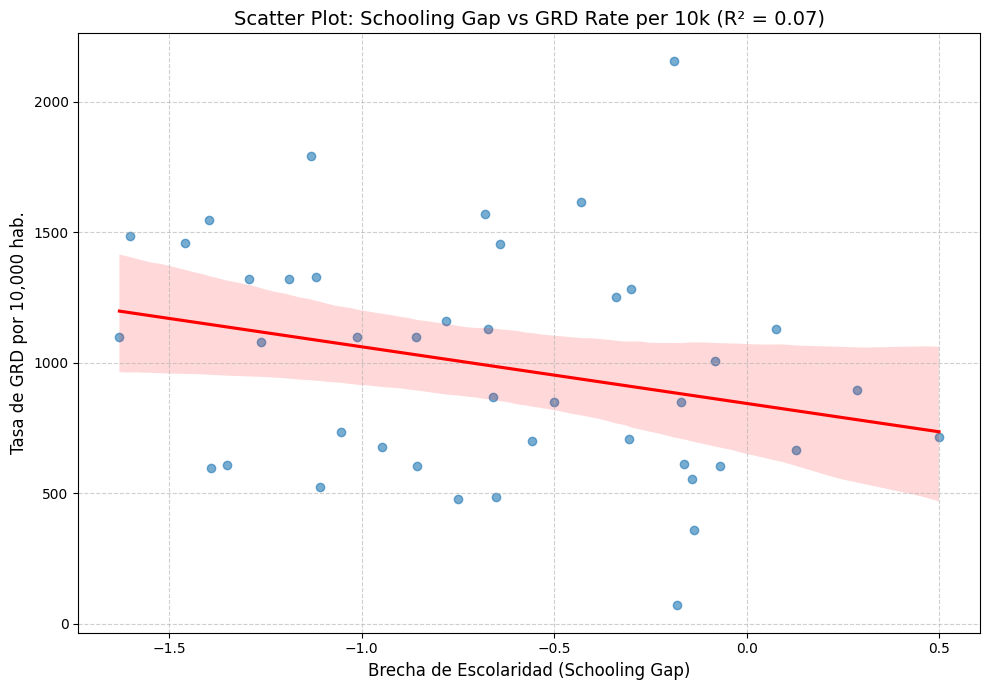

In [70]:
# Asegurarse de que no haya NaN en las variables a usar para la regresión
df_temp_plot = df_final[['schooling_gap', 'grd_rate_per_10k']].dropna()

# Realizar la regresión lineal para obtener el R-cuadrado
slope, intercept, r_value, p_value, std_err = stats.linregress(df_temp_plot['schooling_gap'], df_temp_plot['grd_rate_per_10k'])

plt.figure(figsize=(10, 7))
sns.regplot(
    data=df_temp_plot,
    x='schooling_gap',
    y='grd_rate_per_10k',
    scatter_kws={'alpha':0.6},
    line_kws={'color': 'red'}
)

plt.title(f'Scatter Plot: Schooling Gap vs GRD Rate per 10k (R² = {r_value**2:.2f})', fontsize=14)
plt.xlabel('Brecha de Escolaridad (Schooling Gap)', fontsize=12)
plt.ylabel('Tasa de GRD por 10,000 hab.', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Parte 3: Regresión con resultado continuo (1,5 puntos)

### 3.1 Elija un resultado

Para esta sección, hemos elegido `grd_mean_los` (duración media de la estancia en días) como resultado continuo. Consideramos que es una variable interesante porque nos permite entender qué factores sociodemográficos y de salud en una comuna pueden influir en el tiempo que los pacientes permanecen hospitalizados. Una duración media de estancia más larga podría indicar una mayor complejidad de los casos, falta de recursos para una recuperación temprana o desafíos en la gestión de altas, aspectos que podrían estar relacionados con las covariables censales que hemos estado explorando.

### 3.2 Regresión lineal

In [71]:
# Asegurarse de que no haya NaN en las variables a usar para la regresión
df_model_ols = df_final.dropna(subset=['grd_mean_los', 'pct_foreign', 'schooling_gap', 'pct_unemployed'])

# Definir la variable dependiente y las covariables
Y = df_model_ols['grd_mean_los']
X = df_model_ols[['pct_foreign', 'schooling_gap', 'pct_unemployed']]

# Añadir una constante a las covariables para el intercepto del modelo OLS
X = sm.add_constant(X)

# Ajustar el modelo de regresión lineal (MCO)
ols_model = sm.OLS(Y, X)
ols_results = ols_model.fit()

print("\n--- Tabla de Coeficientes de Regresión Lineal (OLS) para grd_mean_los ---")
display(ols_results.summary())

print(f"\nR²: {ols_results.rsquared:.4f}")
print(f"R² Ajustado: {ols_results.rsquared_adj:.4f}")


--- Tabla de Coeficientes de Regresión Lineal (OLS) para grd_mean_los ---


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:           grd_mean_los   R-squared:                       0.090
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     1.254
Date:                Sun, 03 May 2026   Prob (F-statistic):              0.304
Time:                        22:36:21   Log-Likelihood:                -41.559
No. Observations:                  42   AIC:                             91.12
Df Residuals:                      38   BIC:                             98.07
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              5.5667      0.332     16.744      0.000       4.894       6.240
pct_foreign        0.0194      0.014      1.355      0.183      -0.010       0.048
schooling_gap      0.1205      0.213      0.565      0.575      -0.311       0.552
pct_unemployed     0.4026      0.560      0.719      0.476      -0.730       1.536
==============================================================================
Omnibus:                        0.103   Durbin-Watson:                   2.495
Prob(Omnibus):                  0.950   Jarque-Bera (JB):                0.105
Skew:                           0.090   Prob(JB):                        0.949
Kurtosis:                       2.833   Cond. No.                         75.3
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""


R²: 0.0901
R² Ajustado: 0.0183


### 3.3 Diagnóstico

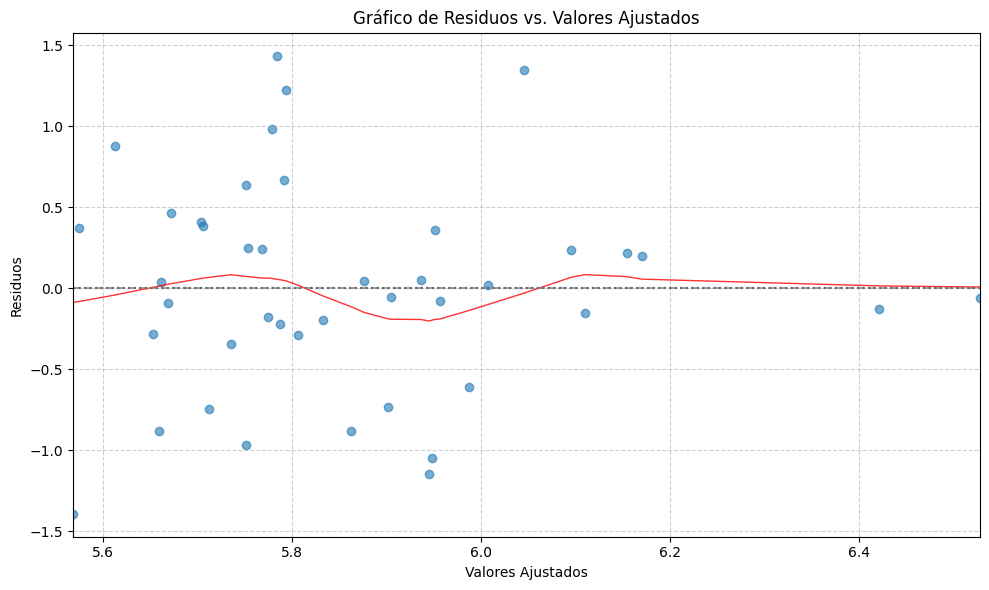

<Figure size 1000x600 with 0 Axes>

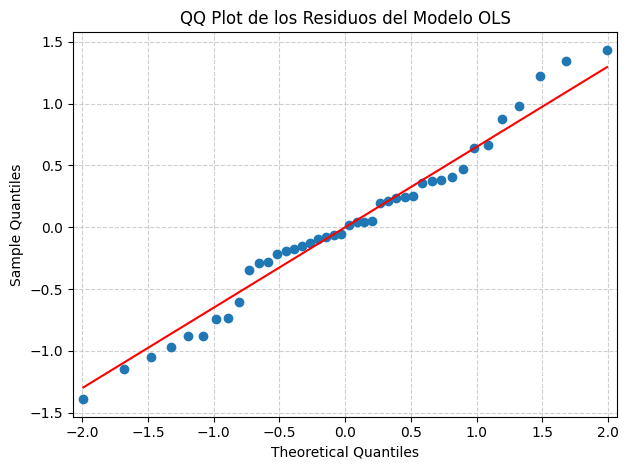

In [72]:
# Gráfico 1: Residuos vs. Valores Ajustados
plt.figure(figsize=(10, 6))
sns.residplot(x=ols_results.fittedvalues, y=ols_results.resid, lowess=True,
              scatter_kws={'alpha': 0.6}, line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8})
plt.title('Gráfico de Residuos vs. Valores Ajustados')
plt.xlabel('Valores Ajustados')
plt.ylabel('Residuos')
plt.axhline(y=0, color='grey', linestyle='--', alpha=0.7)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Gráfico 2: QQ Plot de los Residuos
plt.figure(figsize=(10, 6))
sm.qqplot(ols_results.resid, line='s')
plt.title('QQ Plot de los Residuos del Modelo OLS')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Comentario sobre los supuestos de MCO y alternativas

El modelo OLS simple no es adecuado para predecir `grd_mean_los` con estos datos. Necesitaríamos explorar otras opciones, como transformar algunas variables (por ejemplo, usar su logaritmo), usar métodos de regresión más robustos que manejen mejor los errores no normales, o modelos que puedan lidiar con la multicolinealidad.

## Parte 4: Falacia ecológica (1 punto)

La falacia ecológica nos advierte sobre un error común al interpretar datos en estudios como el nuestro. La clave está en la diferencia entre hablar de **individuos** (personas) y hablar de **grupos** (como nuestras comunas).

### 1. Diferencia entre un nivel individual y una asociación ecológica

Una asociación a nivel individual examina la relación entre variables medidas directamente en cada persona. Por ejemplo, si vemos que las personas que fuman tienen más probabilidad de desarrollar cáncer, esta es una conclusión que se aplica a cada persona.

En cambio, una asociación ecológica examina la relación entre características de un grupo o unidad agregada, como una comuna. En nuestro trabajo, analizamos datos como el porcentaje de extranjeros (`pct_foreign`) y la tasa de enfermedades (`eno_rate_per_10k`) de cada comuna. Si las comunas con más extranjeros tienen más enfermedades, es una asociación ecológica. La conclusión se refiere a la comuna en su conjunto, no a cada persona. La falacia ecológica surge cuando asumimos, erróneamente, que lo que encontramos a nivel de comuna también aplica a cada individuo.

### 2. Ejemplo de malinterpretación de un coeficiente ecológico

Consideremos el coeficiente de `schooling_gap` (brecha de escolaridad entre chilenos y extranjeros) en nuestro modelo de regresión Binomial Negativa para `eno_total`. Observamos un IRR de aproximadamente 15.27. Esto significa que, por cada unidad de aumento en la brecha de escolaridad de una comuna, la tasa esperada de enfermedades en esa comuna se multiplica por 15.27. Es una asociación fuerte a nivel de comuna.

La **interpretación errónea a nivel individual** sería concluir que "los individuos extranjeros con menos escolaridad son 12.53 veces más propensos a contraer una enfermedad que los individuos chilenos con más escolaridad".

Sin embargo, el modelo solo nos dice que una característica de la comuna (la brecha de escolaridad) se relaciona con la tasa de enfermedad general de la comuna. No nos informa sobre la propensión individual a enfermarse basada en la nacionalidad o nivel educativo de una persona.

### 3. Ejemplo de utilidad de la asociación ecológica para la salud pública

Las asociaciones a nivel comunal podrían ser útiles para la planificación de la salud pública. La fuerte relación ecológica entre `schooling_gap` y las tasas de enfermedad (`eno_total`) sugiere que las comunas con una alta brecha de escolaridad deberían ser zonas de alta prioridad para la intervención.

Por ejemplo, un programa de salud pública podría diseñar estrategias específicas para estas comunas, como:
*   Fortalecer los servicios de atención para que sean accesibles para todos.

* Impulsar programas prevención de enfermedades por ugerncia dada según brecha de escolaridad.

*   Implementar campañas de detección activa de enfermedades.

La asociación ecológica no indica *por qué* los individuos se enferman, pero sí dónde la tasa de enfermedades es más alta en relación con ciertas características agregadas, permitiendo, por ejemplo, una asignación más eficiente de recursos y una focalización de las políticas de salud pública a nivel territorial.

### 4. Amenaza adicional para la inferencia: Confusión por variables omitidas

Una amenaza importante es la **confusión por variables omitidas**. Esto ocurre cuando hay otras características relevantes de las comunas que no incluimos en nuestros modelos, pero que están correlacionadas tanto con nuestras variables explicativas (`pct_foreign`, `schooling_gap`) como con los resultados de salud.

Por ejemplo, el nivel socioeconómico (NSE) de una comuna es un fuerte predictor de salud. Si las comunas con un mayor `pct_foreign` también tienden a tener un NSE más bajo, y un NSE más bajo se asocia directamente con peores resultados de salud, entonces el efecto que atribuimos a `pct_foreign` o `schooling_gap` podría estar confundido por este NSE omitido. Sin incluir el NSE, no podemos estar seguros de que el efecto observado sea realmente independiente.

##Parte 5: Visualización espacial de la salida del modelo (1pto)


In [54]:
import sys
!{sys.executable} -m pip install geopandas
!{sys.executable} -m pip install mapclassify


In [73]:
# Carga de datos geoespaciales
comuna_gdf = gpd.read_file('/content/drive/MyDrive/Ramo_IELE756/comunas.shp')

# Preparación para la unión
print("Columnas disponibles en comuna_gdf:")
print(comuna_gdf.columns)

# Asegurarse de que el tipo de dato de cod_comuna sea el mismo para el merge
comuna_gdf['cod_comuna'] = comuna_gdf['cod_comuna'].astype(df_model['codigo_comuna'].dtype)

# Preparación de datos del modelo
# Utilizando los resultados del modelo Binomial Negativo (neg_binom_results)y el dataframe usado para el modelo (df_model)

# Calcular las tasas de notificación previstas por 10,000 habitantes
predicted_eno_total = neg_binom_results.predict(exog=df_model[['pct_foreign', 'schooling_gap', 'pct_unemployed']], offset=df_model['log_pop_total'])
df_model.loc[:, 'predicted_eno_rate_per_10k'] = (predicted_eno_total / np.exp(df_model['log_pop_total'])) * 10000

# Calcular los residuos de Pearson estandarizados
df_model.loc[:, 'pearson_residuals'] = neg_binom_results.resid_pearson

# Unir los datos del modelo con los datos geoespaciales
map_data = comuna_gdf.merge(df_model, left_on='cod_comuna', right_on='codigo_comuna', how='inner')

Columnas disponibles en comuna_gdf:
Index(['objectid', 'shape_leng', 'dis_elec', 'cir_sena', 'cod_comuna',
       'codregion', 'st_area_sh', 'st_length_', 'Region', 'Comuna',
       'Provincia', 'geometry'],
      dtype='object')


/tmp/ipykernel_2130/4234464733.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model.loc[:, 'predicted_eno_rate_per_10k'] = (predicted_eno_total / np.exp(df_model['log_pop_total'])) * 10000
/tmp/ipykernel_2130/4234464733.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model.loc[:, 'pearson_residuals'] = neg_binom_results.resid_pearson


### 5.1 Mapa de tasas previstas

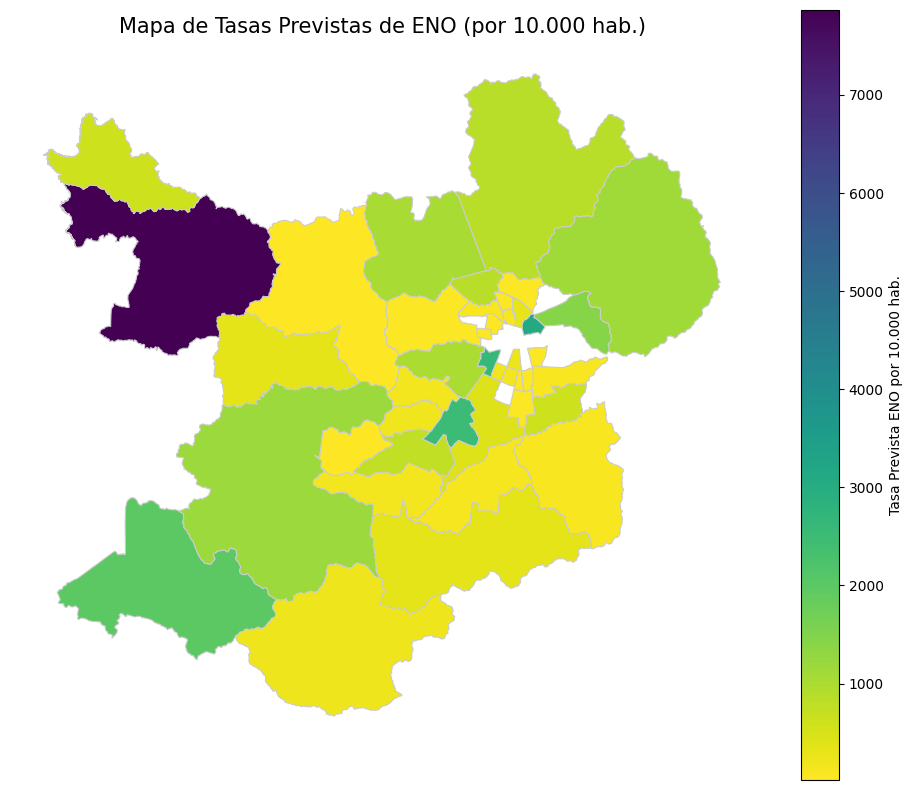

In [56]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(12, 10))
map_data.plot(column='predicted_eno_rate_per_10k',
              cmap='viridis_r',
              linewidth=0.8,
              ax=ax,
              edgecolor='0.8',
              legend=True,
              legend_kwds={'label': "Tasa Prevista ENO por 10.000 hab.", 'orientation': "vertical"})
ax.set_title('Mapa de Tasas Previstas de ENO (por 10.000 hab.)', fontsize=15)
ax.set_axis_off()
plt.show()

### 5.2 Mapa residual

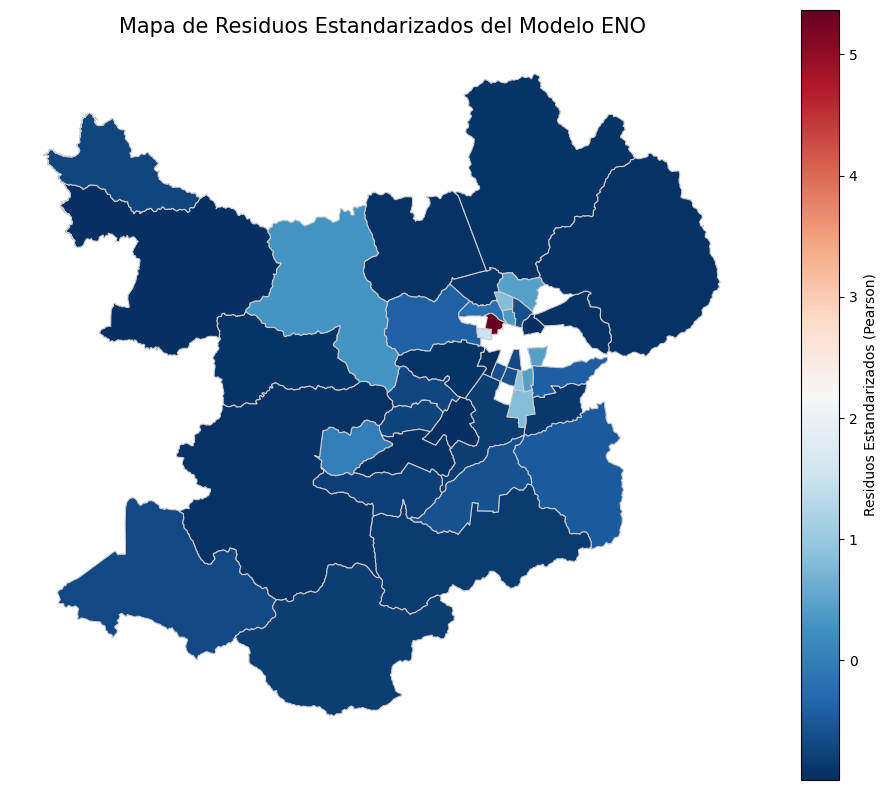


Comunas con los mayores residuos positivos (subestimadas por el modelo):


,nombre_comuna,pearson_residuals
27,Quinta Normal,5.366729
22,Lo Prado,1.500498
1,San Ramón,0.940554
15,Conchalí,0.827169
18,La Pintana,0.805849



Comunas con los mayores residuos negativos (sobrestimadas por el modelo):


,nombre_comuna,pearson_residuals
7,Lampa,-0.956246
4,Providencia,-0.967483
14,Cerrillos,-0.971053
29,Casablanca,-0.986703
5,Calera de Tango,-0.986857


In [57]:
import matplotlib.pyplot as plt


fig, ax = plt.subplots(1, 1, figsize=(12, 10))
map_data.plot(column='pearson_residuals',
              cmap='RdBu_r', # Paleta divergente centrada en cero
              linewidth=0.8,
              ax=ax,
              edgecolor='0.8',
              legend=True,
              legend_kwds={'label': "Residuos Estandarizados (Pearson)", 'orientation': "vertical"})
ax.set_title('Mapa de Residuos Estandarizados del Modelo ENO', fontsize=15)
ax.set_axis_off()
plt.show()

# Identificación de comunas con mayores residuos
# Ordenar por residuos para encontrar los extremos
residuals_sorted = map_data.sort_values(by='pearson_residuals', ascending=False)

print("\nComunas con los mayores residuos positivos (subestimadas por el modelo):")
display(residuals_sorted[['nombre_comuna', 'pearson_residuals']].head(5))

print("\nComunas con los mayores residuos negativos (sobrestimadas por el modelo):")
display(residuals_sorted[['nombre_comuna', 'pearson_residuals']].tail(5))

### 5.3 Gráfico de coeficientes (Forest Plot)

Generamos un gráfico de coeficientes para el modelo de regresión Binomial Negativa de `eno_total`. Este gráfico muestra las Razones de Tasas de Incidencia (IRR) y sus intervalos de confianza del 95% para cada covariable, permitiendo una visualización clara del efecto de cada predictor en la tasa de notificaciones ENO.

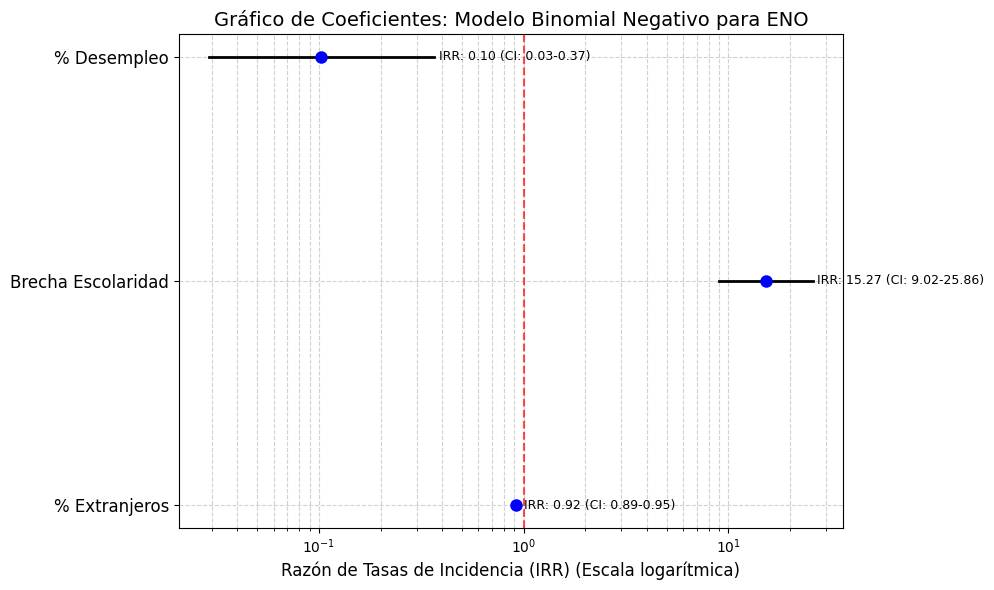

In [74]:
# Usamos irr_summary_nb del resultado de la celda 861ce6cc
# Aseguramos que el índice sea el nombre de la variable para el gráfico.
coef_df = irr_summary_nb.copy()
coef_df.index = ['% Extranjeros', 'Brecha Escolaridad', '% Desempleo']

# Crear el gráfico de coeficientes (Forest Plot)
fig, ax = plt.subplots(figsize=(10, 6))

# Plotear los intervalos de confianza
for i, (param, row) in enumerate(coef_df.iterrows()):
    # La estimación puntual del IRR
    irr_val = row['IRR_NB']

    # Los límites del intervalo de confianza del IRR
    lower_ci = row['IRR_Lower_CI_NB']
    upper_ci = row['IRR_Upper_CI_NB']

    # Línea horizontal para el intervalo de confianza
    ax.plot([lower_ci, upper_ci], [i, i], 'k-', lw=2)

    # Marcador para la estimación puntual
    ax.plot(irr_val, i, 'o', color='blue', markersize=8)

    # Opcional: Anotar el valor del IRR y CI junto al punto
    ax.text(upper_ci * 1.05, i, f"IRR: {irr_val:.2f} (CI: {lower_ci:.2f}-{upper_ci:.2f})",
            va='center', ha='left', fontsize=9)

# Añadir una línea vertical en IRR = 1 (valor nulo para las razones de tasas)
ax.axvline(x=1, color='red', linestyle='--', lw=1.5, alpha=0.7)

# Configuración del eje y
ax.set_yticks(range(len(coef_df)))
ax.set_yticklabels(coef_df.index, fontsize=12)

# Escala logarítmica para el eje x, ya que son IRRs
ax.set_xscale('log')
ax.set_xlabel('Razón de Tasas de Incidencia (IRR) (Escala logarítmica)', fontsize=12)
ax.set_title('Gráfico de Coeficientes: Modelo Binomial Negativo para ENO', fontsize=14)
ax.grid(True, which="both", ls="--", c='0.7', alpha=0.6)

plt.tight_layout()
plt.show()

## Parte 6: Síntesis Integrada

### 1. Perfil Demográfico y Eje Dominante

El retrato demográfico de la Región Metropolitana a nivel comunal (Tarea 1) revela una notable diversidad. Las 45 comunas analizadas (tras la exclusión de Santiago por un dato anómalo en `pct_foreign`) muestran variaciones significativas en su población total, el porcentaje de población extranjera (`pct_foreign`), las tasas de empleo/desempleo, y la brecha de escolaridad (`schooling_gap`) entre chilenos y extranjeros. Por ejemplo, `pct_foreign` varía desde aproximadamente el 2% hasta más del 15% en algunas comunas, y la `schooling_gap` muestra rangos que van desde -1.6 hasta 0.5 años (ref. `df_final.describe()`). El eje dominante de variación a través de las comunas se perfila en torno a la **composición de la población extranjera y su nivel educativo en comparación con la población chilena**. Esto se evidencia en la importancia que variables como `pct_foreign` y `schooling_gap` adquieren en las correlaciones y, más prominentemente, en los modelos multivariados.

### 2. Relación entre el Paisaje Sanitario y el Eje Demográfico

Al mapear el paisaje sanitario, representado por las tasas de enfermedades ENO y egresos hospitalarios GRD, sobre este eje demográfico, se observan tanto coincidencias como desajustes. Inicialmente, el análisis de correlación simple, tras excluir a Santiago, mostró correlaciones débiles o moderadas:

*   `pct_foreign` presentó una correlación positiva débil con `eno_rate_per_10k` (0.22) y muy débil con `grd_rate_per_10k` (0.025).
*   `schooling_gap` tuvo una correlación positiva débil con `eno_rate_per_10k` (0.30) y negativa débil con `grd_rate_per_10k` (-0.27).
*   `pct_unemployed` mostró correlaciones negativas muy débiles con ambas tasas de salud.

La identificación y exclusión del valor atípico de 'Santiago' (con un `pct_foreign` inviable de 3047.81%) fue crucial. Antes de su remoción, este punto extremo distorsionaba las correlaciones, sugiriendo una relación engañosamente fuerte y positiva entre `pct_foreign` y las tasas de salud. Este es un claro ejemplo de dónde la limpieza de datos es fundamental para evitar interpretaciones erróneas y cómo un solo punto puede generar una distorción en los resultados.

# Anexo

In [76]:
new_export_path = '/content/drive/MyDrive/Ramo_IELE756/Tareas/csv outputs/'

# Ensure the directory exists
os.makedirs(new_export_path, exist_ok=True)

df_census_master.to_csv(os.path.join(new_export_path, 'census_master.csv'), index=False)
df_eno_master.to_csv(os.path.join(new_export_path, 'eno_master.csv'), index=False)
df_grd_master.to_csv(os.path.join(new_export_path, 'grd_master.csv'), index=False)

print(f"'census_master.csv' exported to {new_export_path}")
print(f"'eno_master.csv' exported to {new_export_path}")
print(f"'grd_master.csv' exported to {new_export_path}")

'census_master.csv' exported to /content/drive/MyDrive/Ramo_IELE756/Tareas/csv outputs/
'eno_master.csv' exported to /content/drive/MyDrive/Ramo_IELE756/Tareas/csv outputs/
'grd_master.csv' exported to /content/drive/MyDrive/Ramo_IELE756/Tareas/csv outputs/
